<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Variation: Time-evolving potential</p>
    <o style='font-size:20px;'>How does accounting for the mass-growth of the Milky Way after BHs?</p>
</div>

In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Load data

In [3]:
reload(constants)
files = ["fiducial", "time-evolving-pot"]
labels = ["Static", "Time-evolving"]
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [5]:
pops, data = helpers.load_postprocessed_pops(
    [f"/mnt/ceph/users/twagg/underworld/postprocessed/{file}" for file in files],
    labels, colours
)

Loading post-processed data for Static from /mnt/ceph/users/twagg/underworld/postprocessed/fiducial
Loading post-processed data for Time-evolving from /mnt/ceph/users/twagg/underworld/postprocessed/time-evolving-pot


# Escape fractions

In [6]:
for pop in pops:
    f_esc = data[pop.label]["escaped"]["BH"].sum() / len(data[pop.label]["escaped"]["BH"])
    print(f"{pop.label}: {f_esc * 100:.1f}%")

Static: 2.7%
Time-evolving: 6.8%


## Escape timing

Evolving case has earlier escapes

Mean escape time (static): 4.243101257945913
Mean escape time (time-evolving): 3.4366804645321327


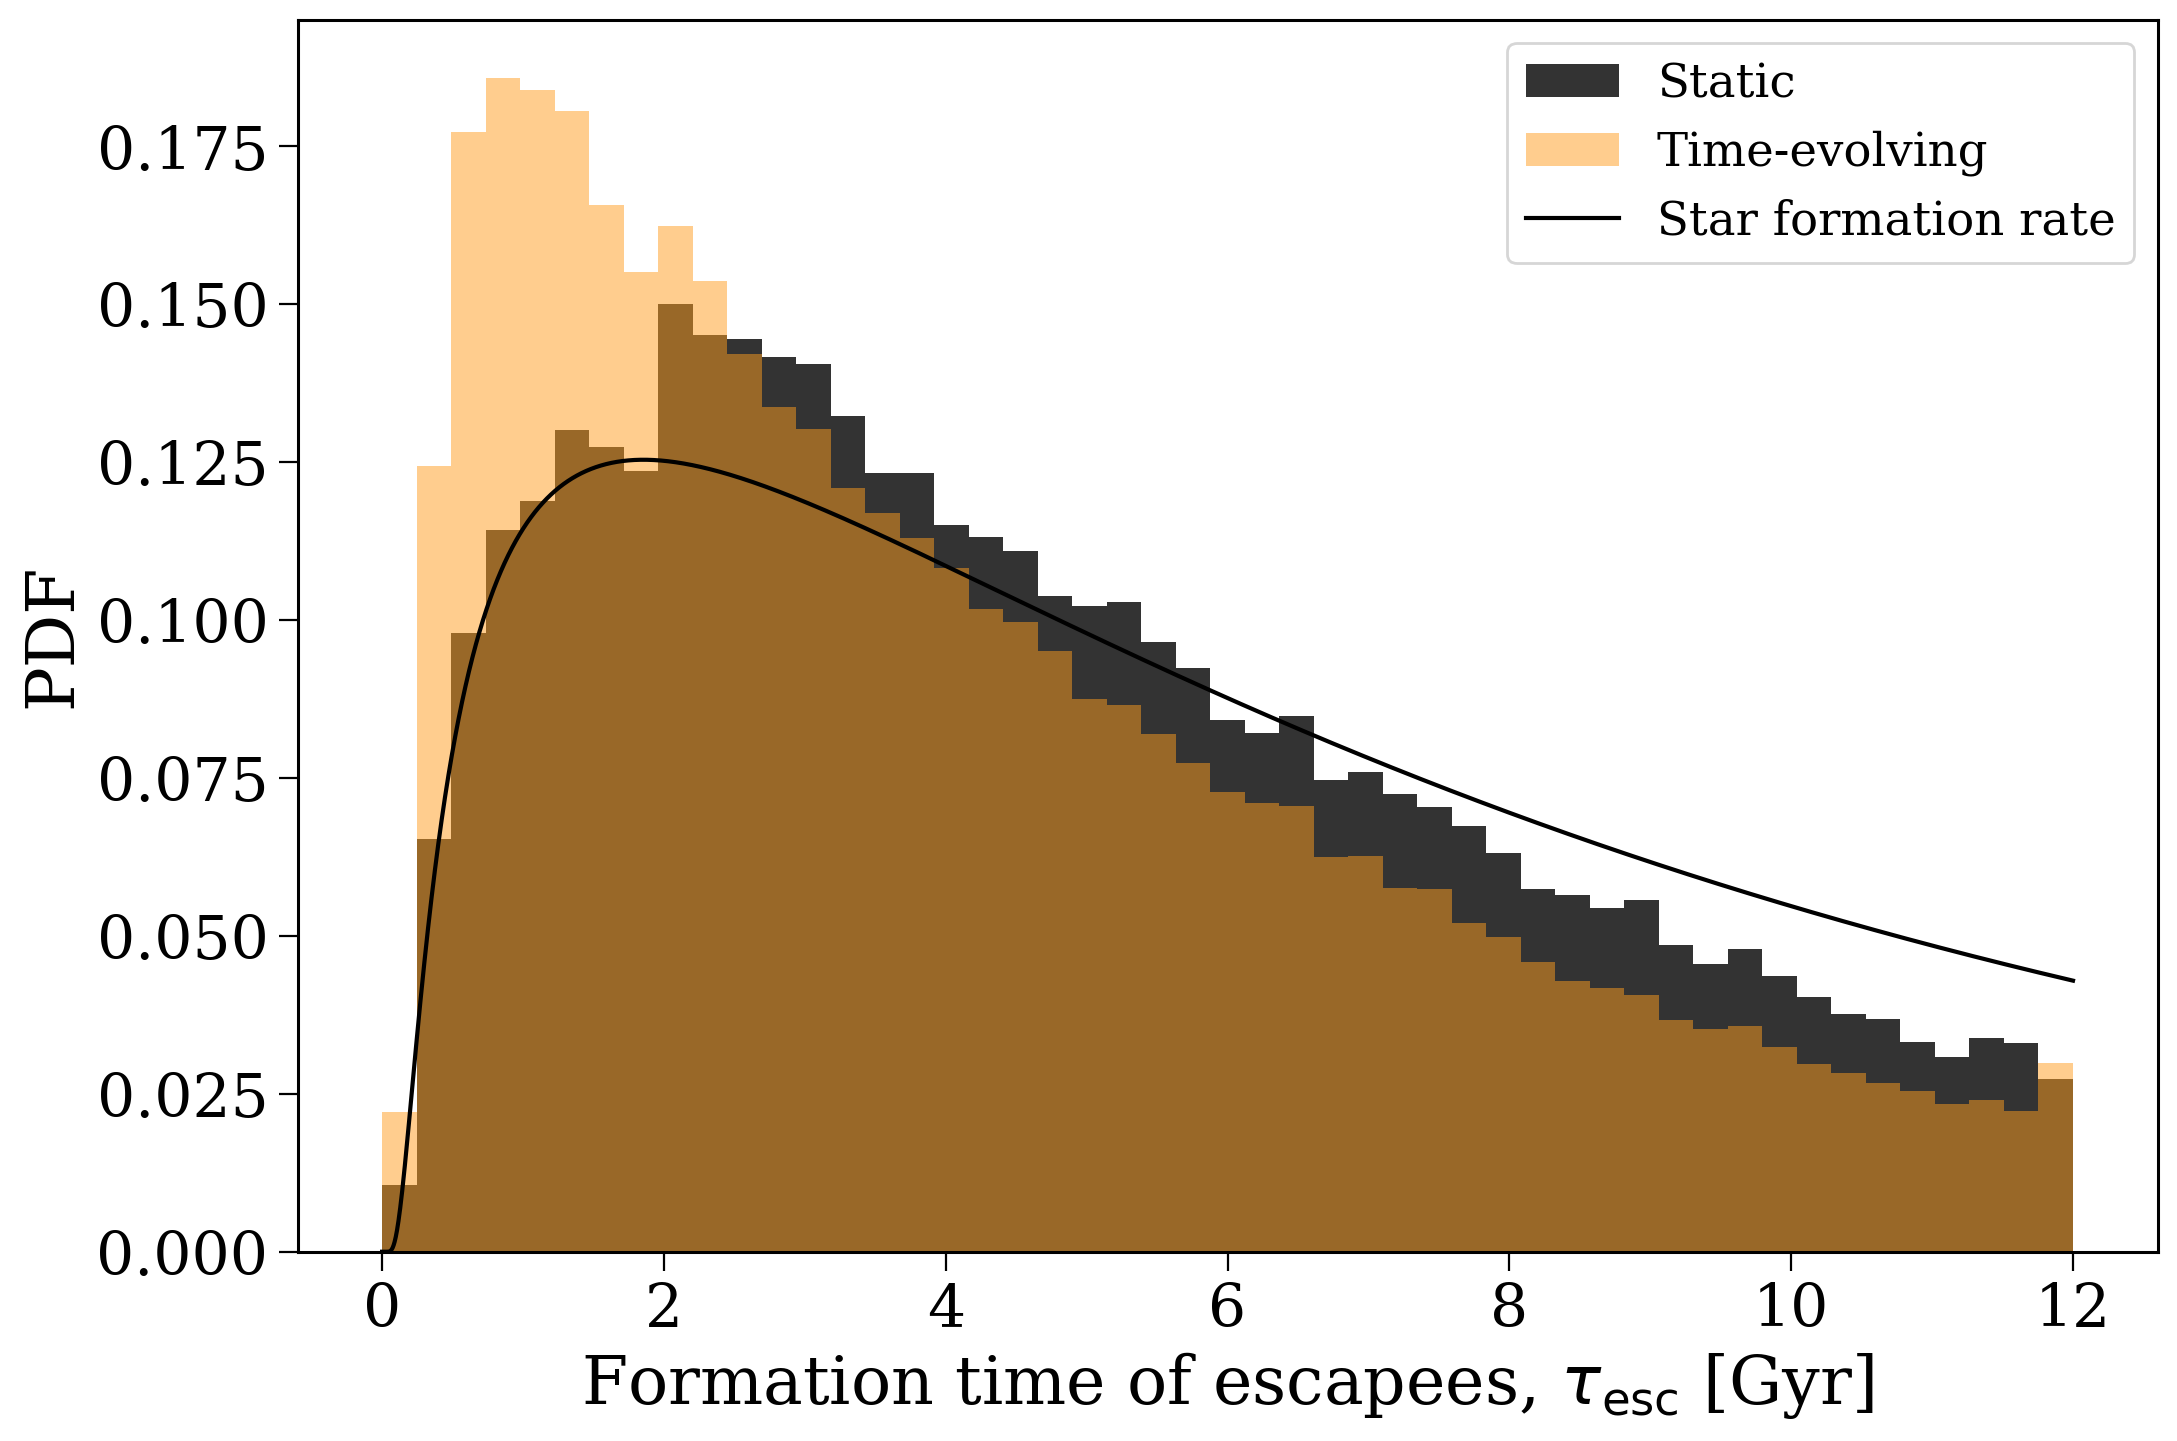

In [7]:
tau_range = np.linspace(0, 12, 100000)
valid = (tau_range >= 0) & (tau_range < 12)
tau_pdf = np.zeros_like(tau_range)
tau_pdf[valid] = np.exp(tau_range[valid] / 8 - 0.43 / (12 - tau_range[valid]))
tau_pdf /= cumulative_trapezoid(tau_pdf, tau_range, initial=0)[-1]

fig, ax = plt.subplots()

bins = np.linspace(0, 12, 50)

ax.hist(12 - data["Static"]["tau"]["BH"][data["Static"]["escaped"]["BH"]], bins=bins, density=True, color=constants.FILE_TO_COLOUR["fiducial"], label="Static");
ax.hist(12 - data["Time-evolving"]["tau"]["BH"][data["Time-evolving"]["escaped"]["BH"]], bins=bins, alpha=0.5, density=True,
        color=constants.FILE_TO_COLOUR["time-evolving-pot"], label="Time-evolving");
ax.plot(12 - tau_range, tau_pdf, color="k", label="Star formation rate")

ax.set(
    xlabel=r"Formation time of escapees, $\tau_\mathrm{esc}$ [Gyr]",
    ylabel="PDF",
)
ax.legend()

print("Mean escape time (static):", np.median(12 - data["Static"]["tau"]["BH"][data["Static"]["escaped"]["BH"]]))
print("Mean escape time (time-evolving):", np.median(12 - data["Time-evolving"]["tau"]["BH"][data["Time-evolving"]["escaped"]["BH"]]))

plt.show()

Inner 10 kpc
  Static fraction within 0.5 kpc 0.53
  Time-evolving fraction within 0.5 kpc 0.50
Full population
  Static fraction within 0.5 kpc 0.49
  Time-evolving fraction within 0.5 kpc 0.44


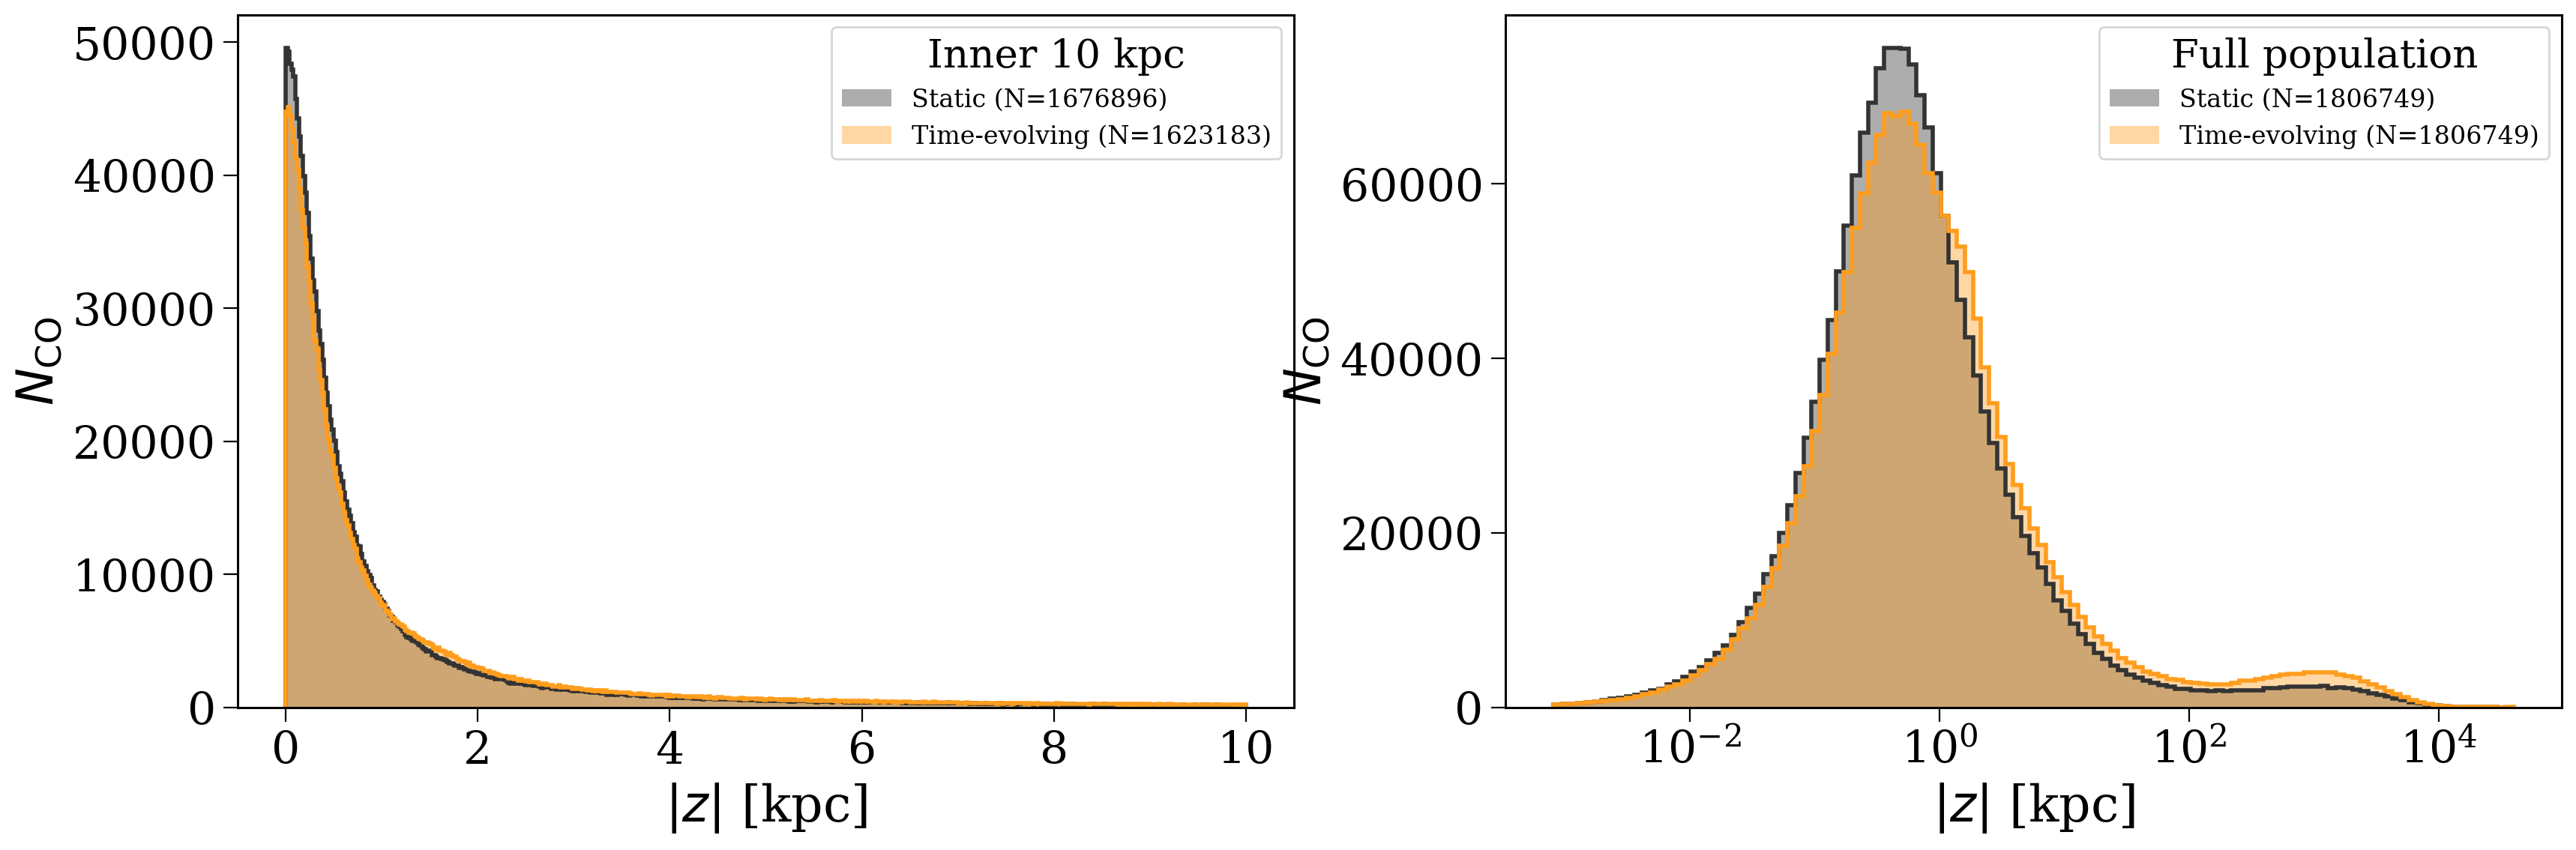

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [65]:
reload(plotting)
plotting.absolute_galactocentric_height(pops, data, co_type="BH")

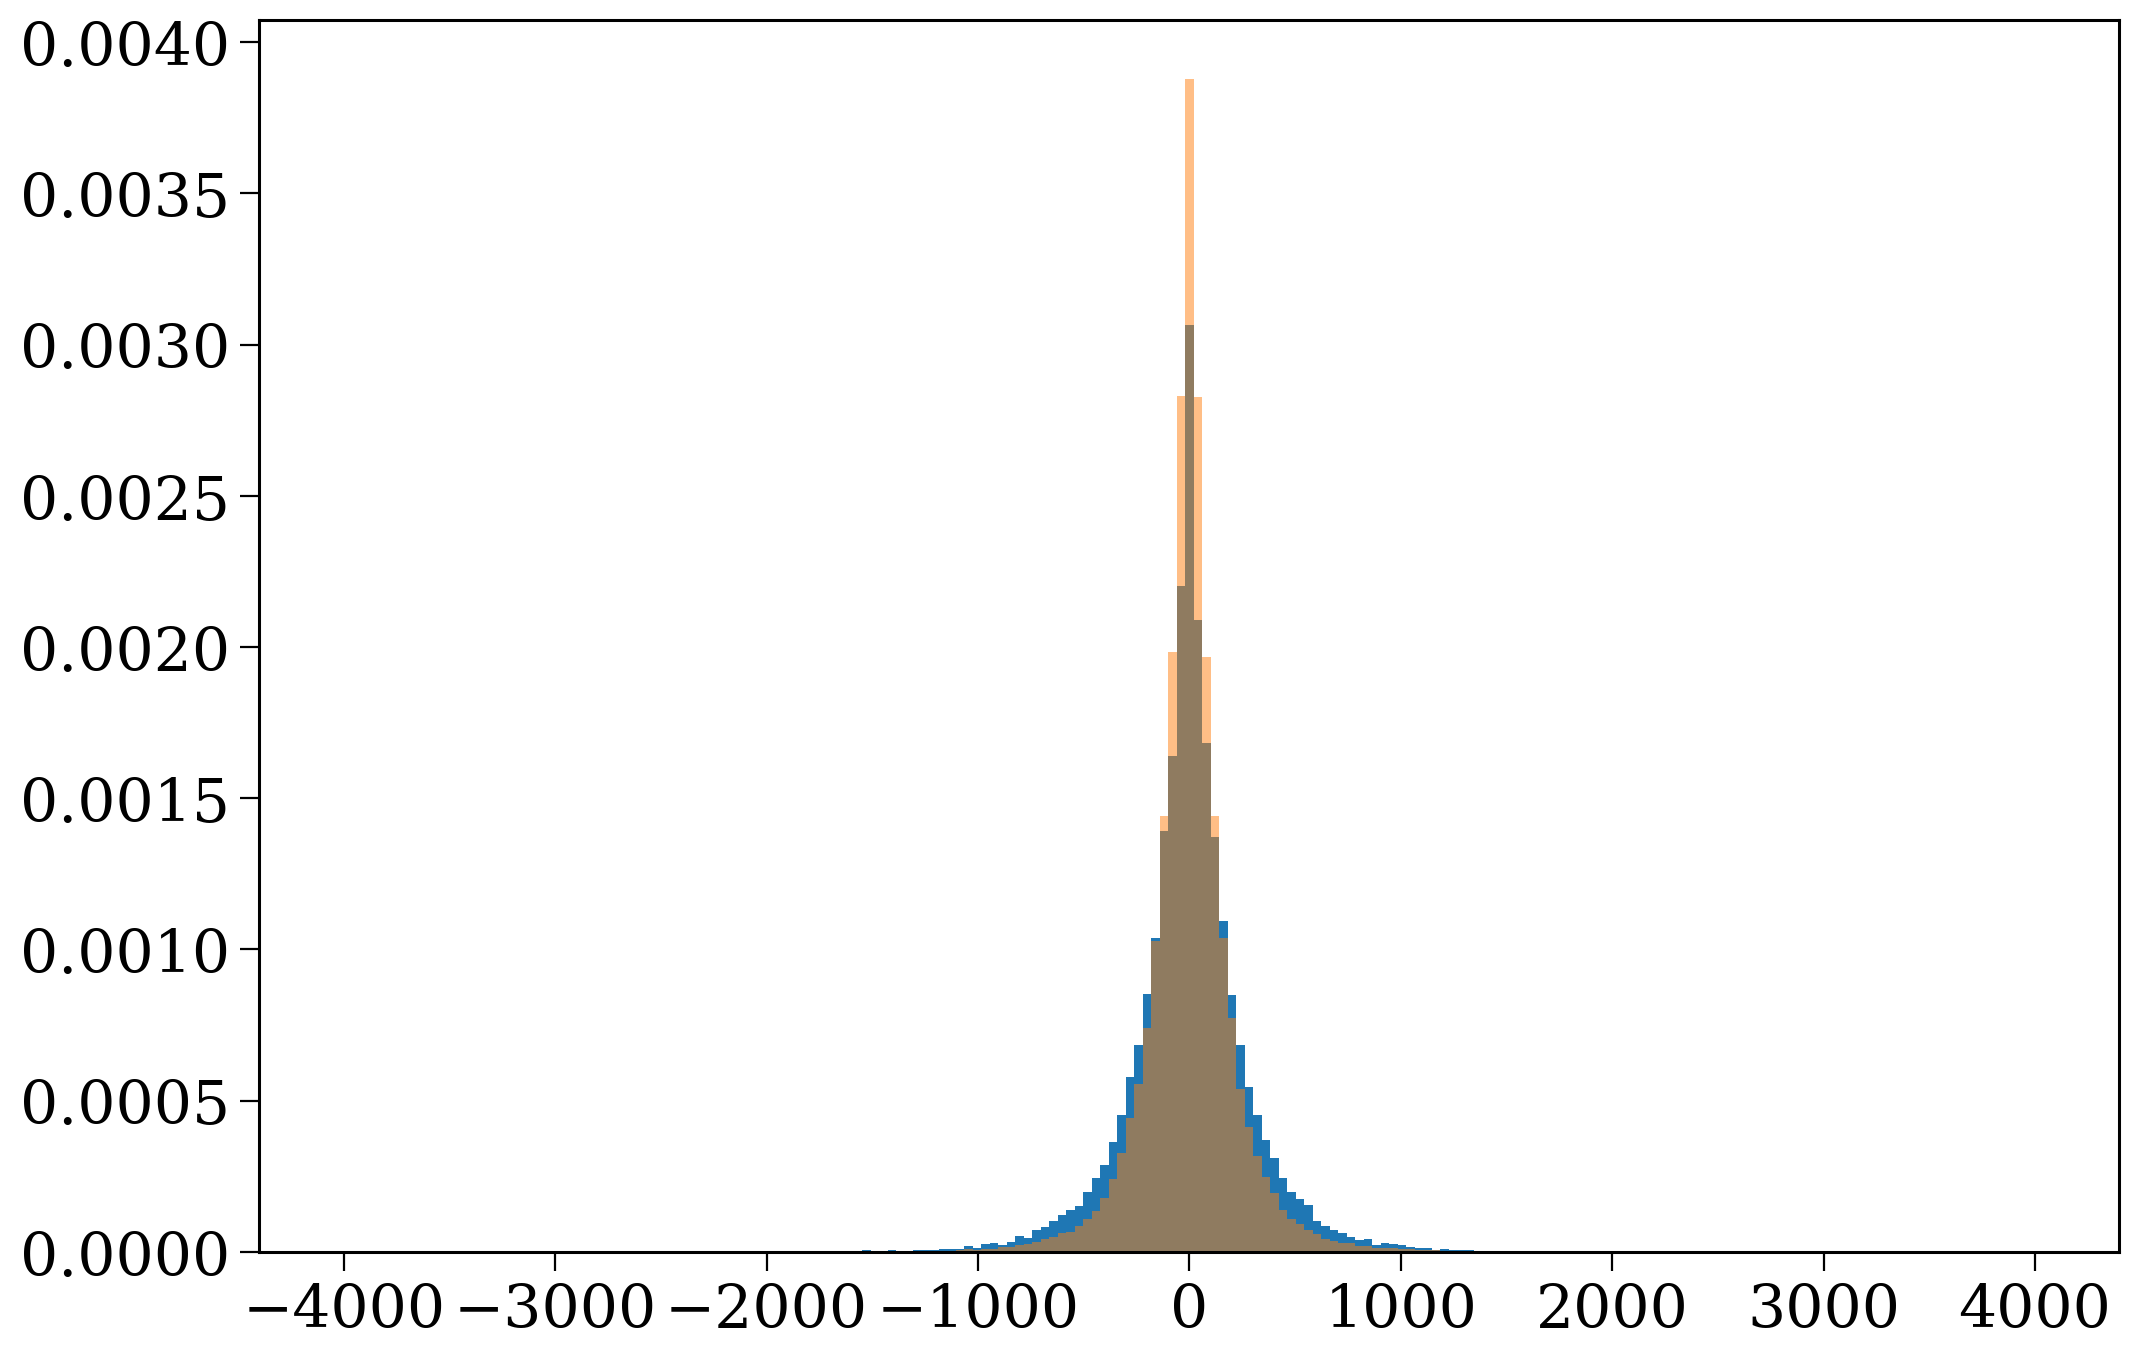

In [67]:
plt.hist(data["Static"]["vel"]["BH"][:, 2][data["Static"]["escaped"]["BH"]], bins=np.linspace(-4000, 4000, 200), density=True);
plt.hist(data["Time-evolving"]["vel"]["BH"][:, 2][data["Time-evolving"]["escaped"]["BH"]], bins=np.linspace(-4000, 4000, 200), density=True, alpha=0.5);

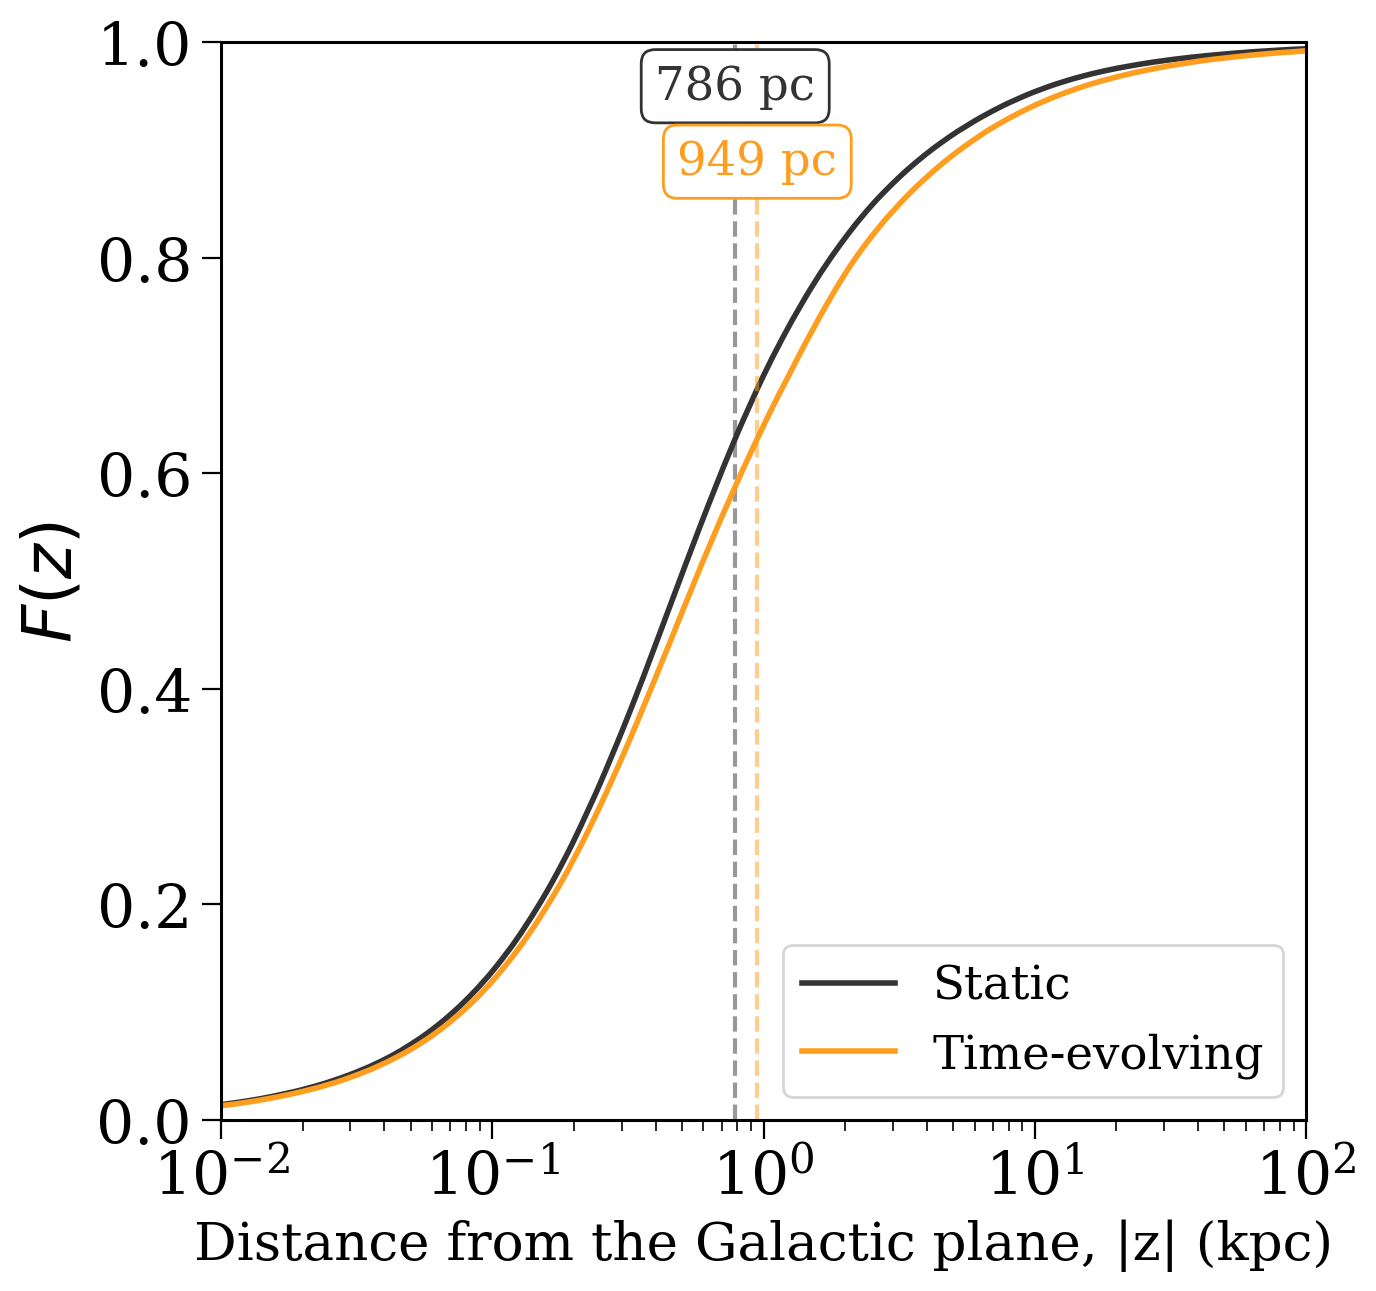

In [8]:
reload(plotting)

fig, ax = plt.subplots(figsize=(7, 7))


for i, pop in enumerate(pops):
    sh = plotting.estimate_scale_height_cdf(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1),
        scale_height_loc=0.98 - i * 0.07,
        R=None,
    )[0]

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_time_evolving.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Analytic stuff

In [9]:
@np.vectorize
def dm_mass_growth_at_tau(tau):
    if tau > 9:
        return (2.32 - (0.88 - 0.4) / 3 * tau)
    else:
        return (1 - 12 / 900 * tau)

In [22]:
def f_from_tau(tau):
    return 1 / dm_mass_growth_at_tau(tau)

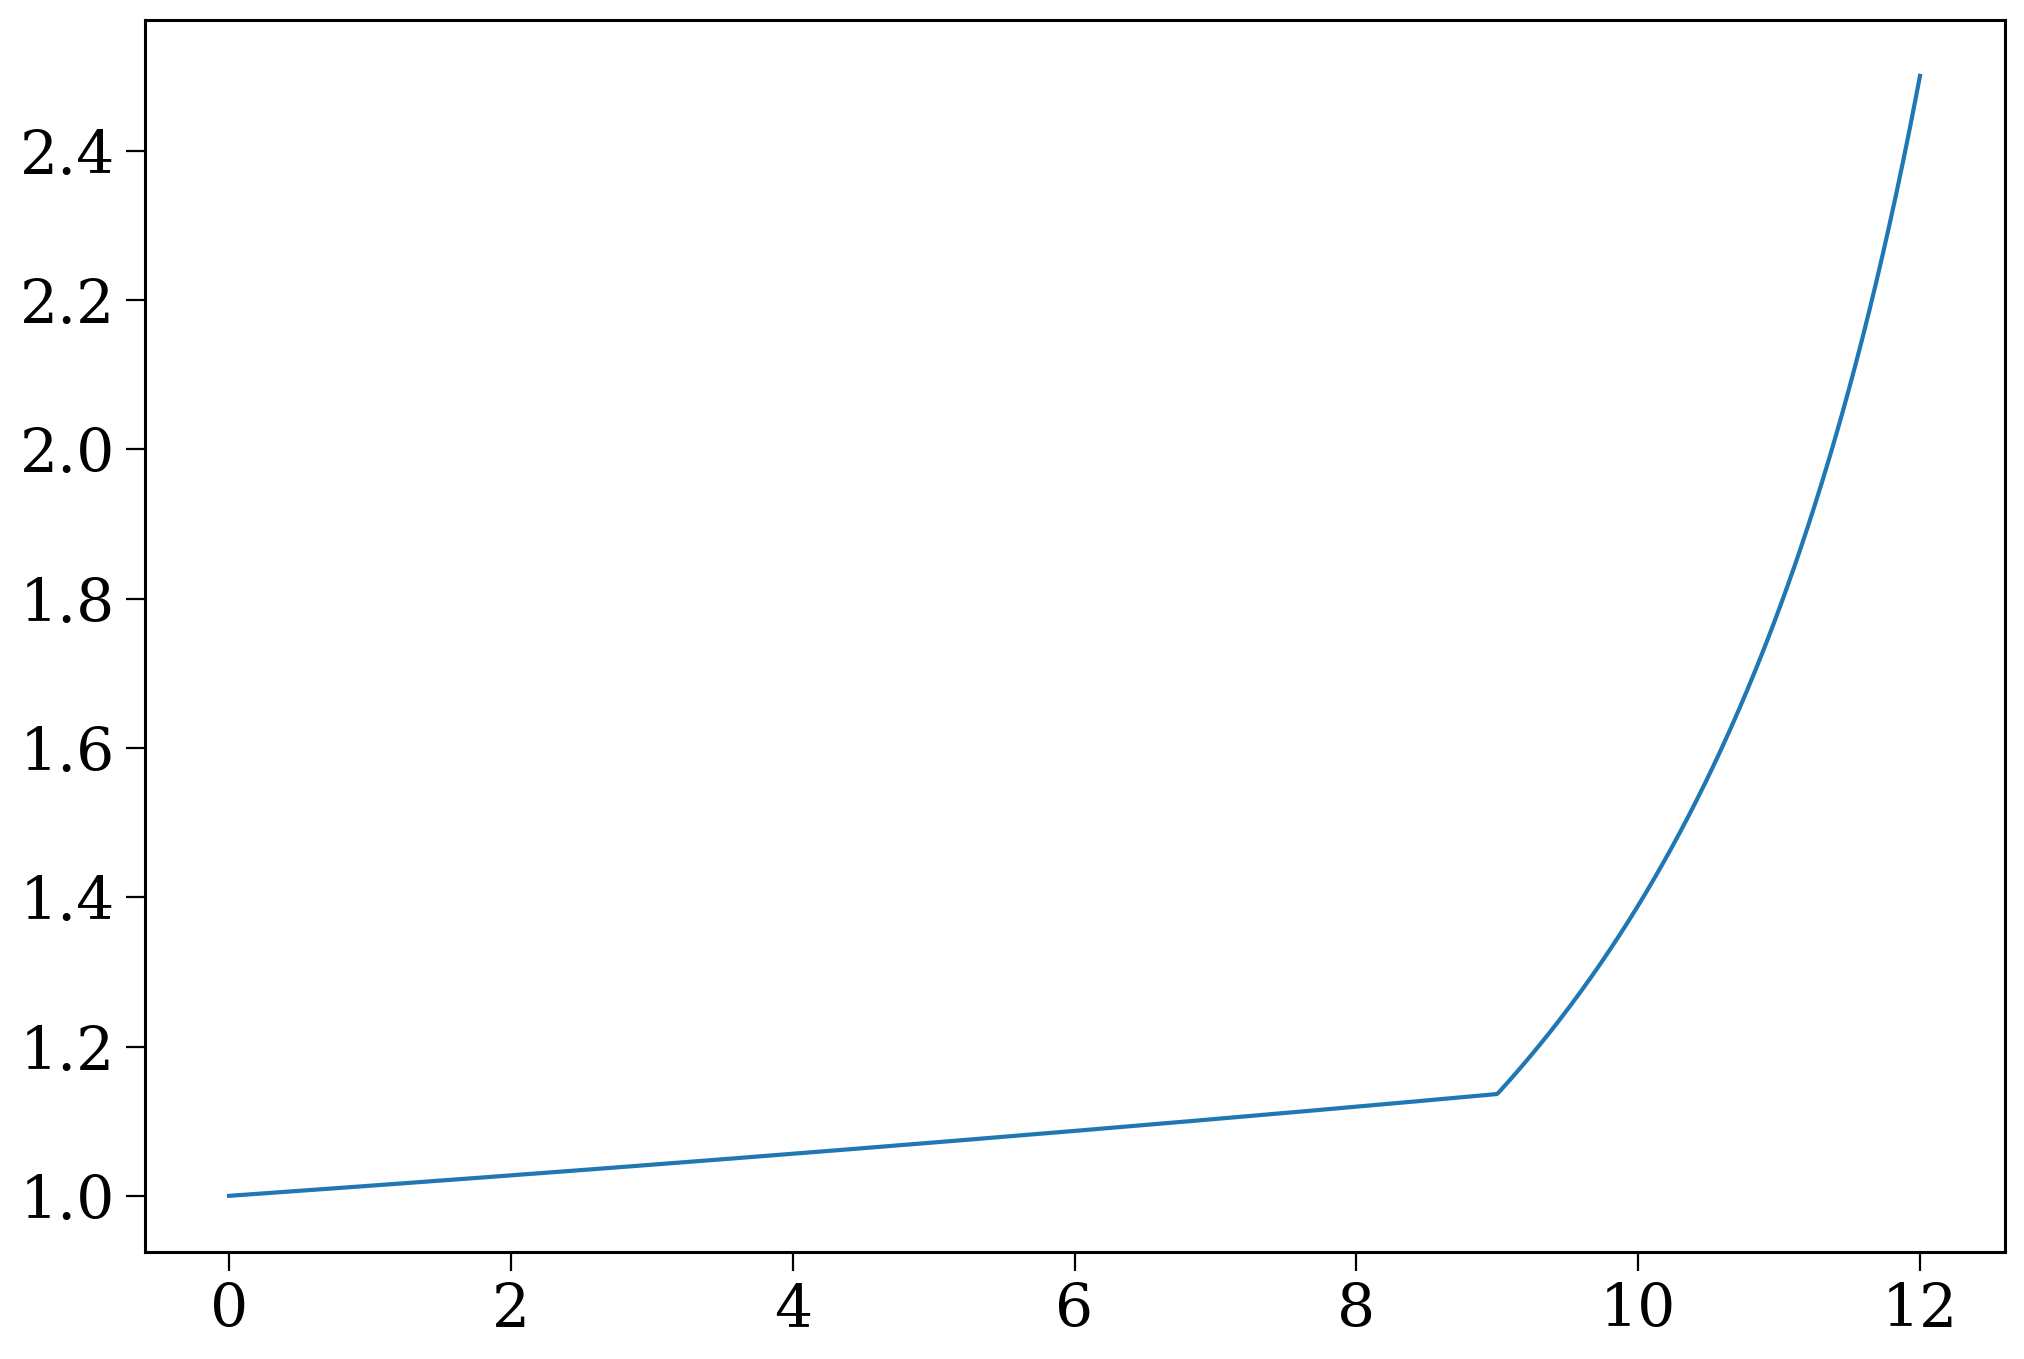

In [44]:
plt.plot(tau_range, f_from_tau(tau_range))

In [45]:
from scipy.interpolate import interp1d
tau_range = np.linspace(0, 12, 10000)
f_vals = 1 / dm_mass_growth_at_tau(tau_range)

tau_from_f = interp1d(f_vals, tau_range)

In [46]:
def p_of_tau(tau):
    tau_f = 8
    tau_s = 0.43
    tau_m = 12
    p = np.exp(tau / tau_f - tau_s / (tau_m - tau))
    return p / cumulative_trapezoid(p, tau_range, initial=0)[-1]

/tmp/ipykernel_3360379/2740111250.py:5: RuntimeWarning: divide by zero encountered in divide
  p = np.exp(tau / tau_f - tau_s / (tau_m - tau))


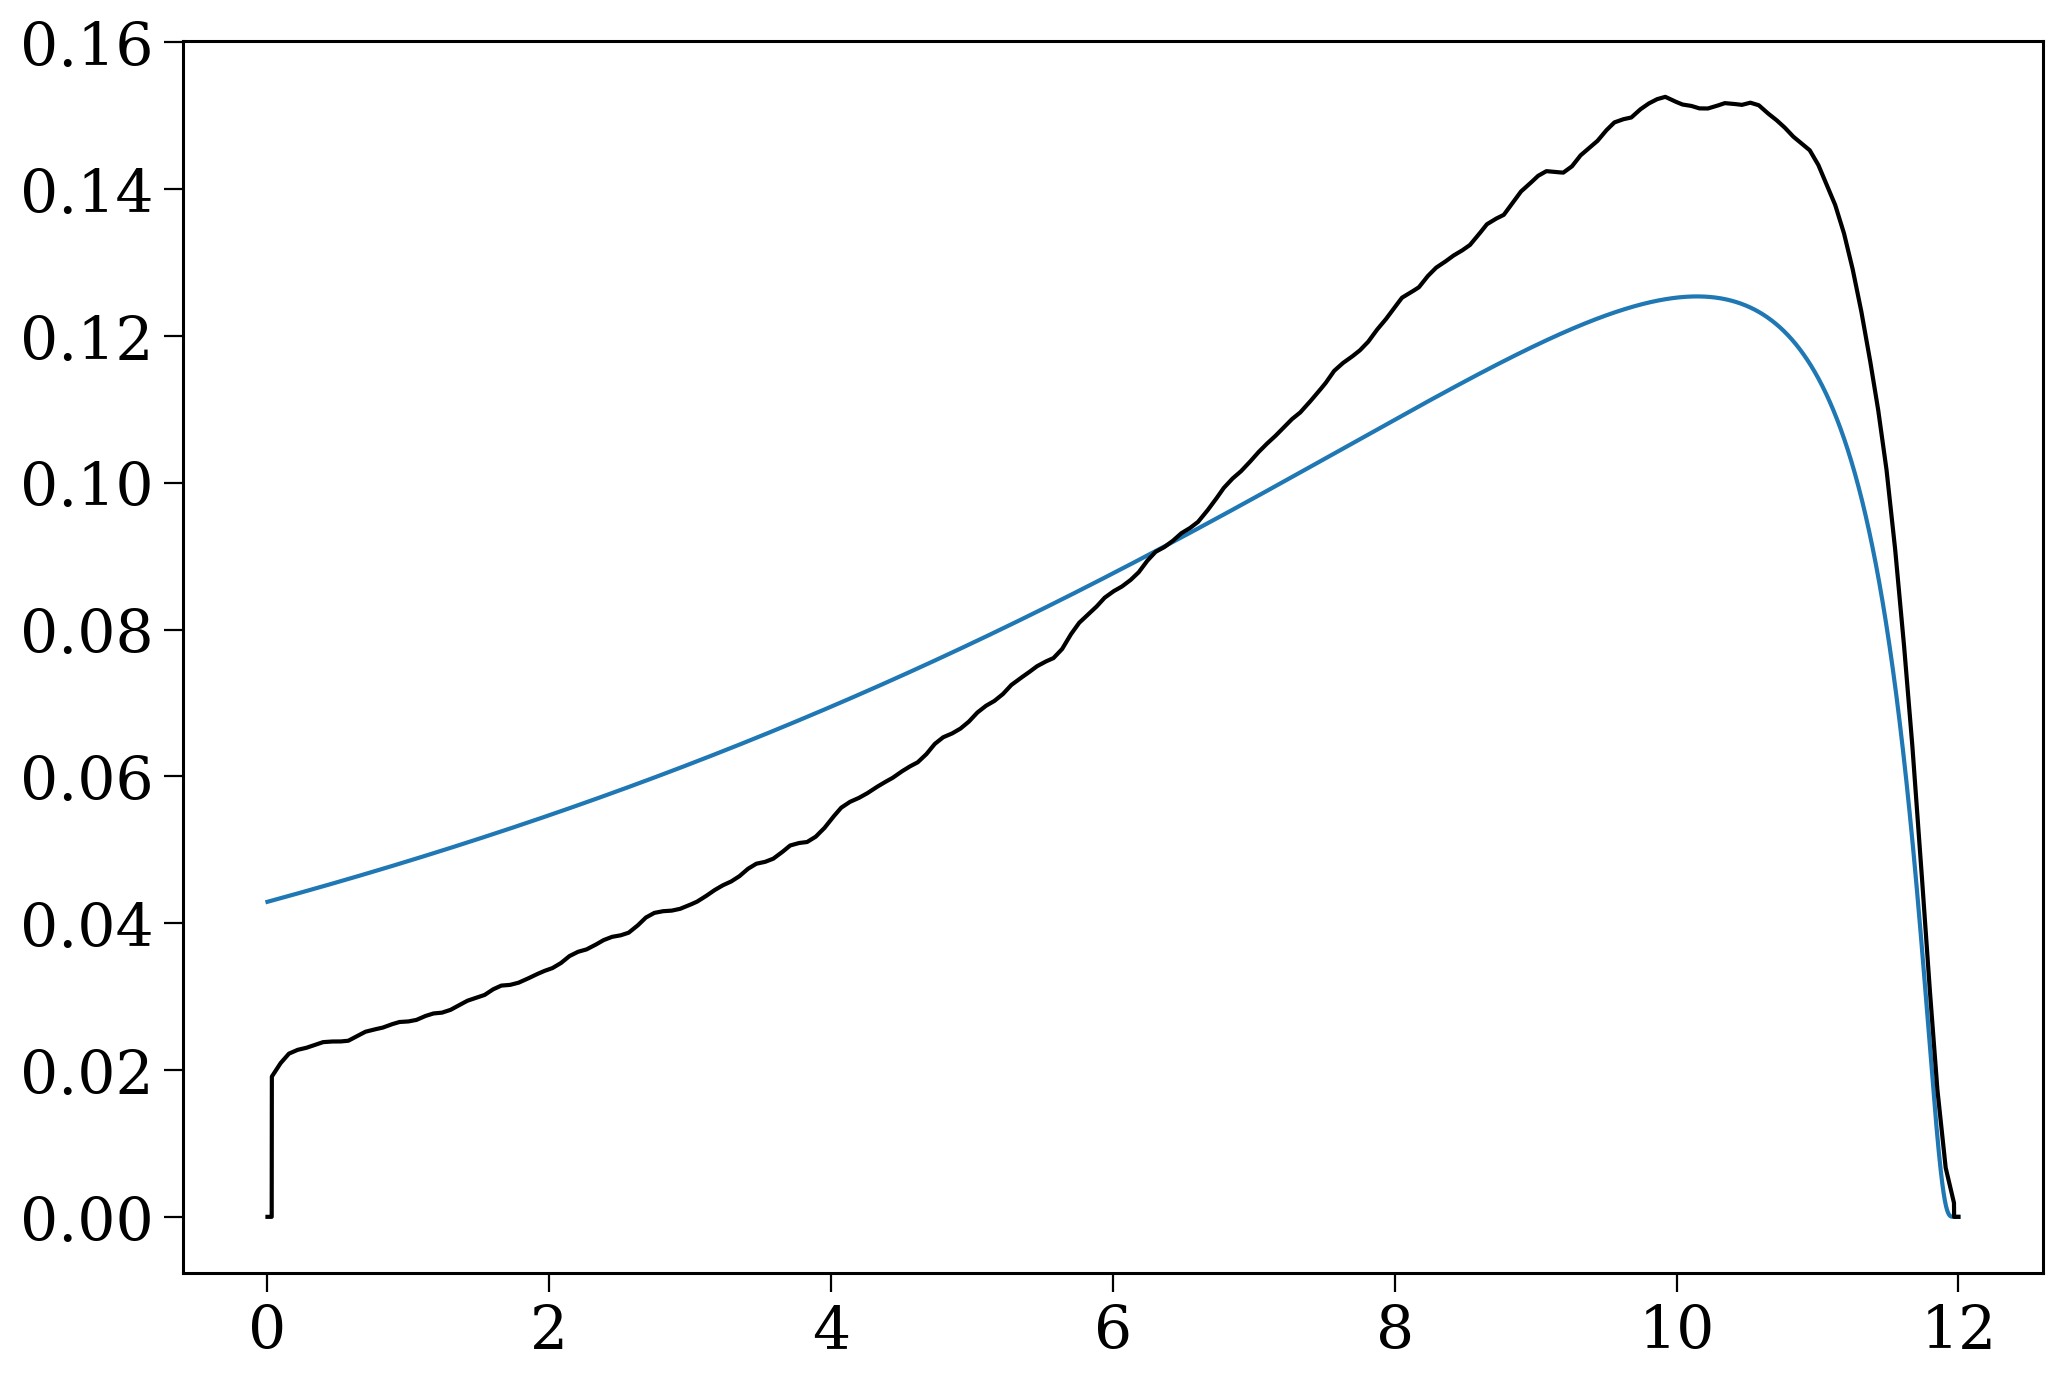

In [47]:
# interpolate a histogram of the tau values of BHs
bins = np.linspace(0, 12, 200)
hist = np.histogram(data["Static"]["tau"]["BH"], bins=bins, density=True)[0]
bin_centres = 0.5 * (bins[:-1] + bins[1:])

# apply some smoothing to the histogram using a Gaussian kernel
from scipy.ndimage import gaussian_filter1d
hist = gaussian_filter1d(hist, sigma=1)

p_of_tau_interp = interp1d(bin_centres, hist, bounds_error=False, fill_value=0)

plt.plot(tau_range, p_of_tau(tau_range))
# plt.hist(data["Static"]["tau"]["BH"], bins=100, density=True, color=constants.FILE_TO_COLOUR["fiducial"], label="Static");
plt.plot(tau_range, p_of_tau_interp(tau_range), color="k", label="Interpolated histogram")

In [48]:
import numpy as np
from scipy import integrate

def mean_scale_height_factor(tau_range, p_of_tau_interp, f_from_tau):
    """
    compute the average scale height increase factor, weighted by
    the star formation history.

    parameters
    ----------
    tau_range : array
        time values over which to integrate (same units as your interpolators)
    p_of_tau_interp : callable
        normalised probability of a star forming at time tau
    f_from_tau : callable
        surface mass growth factor at formation time tau

    returns
    -------
    mean_factor : float
        mass-weighted average scale height factor <f^(1/4)>
    """
    def integrand(tau):
        return p_of_tau_interp(tau) * f_from_tau(tau) ** (1 / 4)

    numerator, _ = integrate.quad(integrand, tau_range[0], tau_range[-1])

    # re-normalise in case p_of_tau isn't perfectly normalised over this range
    denominator, _ = integrate.quad(p_of_tau_interp, tau_range[0], tau_range[-1])

    return numerator / denominator

mean_scale_height_factor(tau_range, p_of_tau_interp, f_from_tau)

/tmp/ipykernel_3360379/2497813530.py:26: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  numerator, _ = integrate.quad(integrand, tau_range[0], tau_range[-1])
/tmp/ipykernel_3360379/2497813530.py:29: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on t

1.0552582975504305

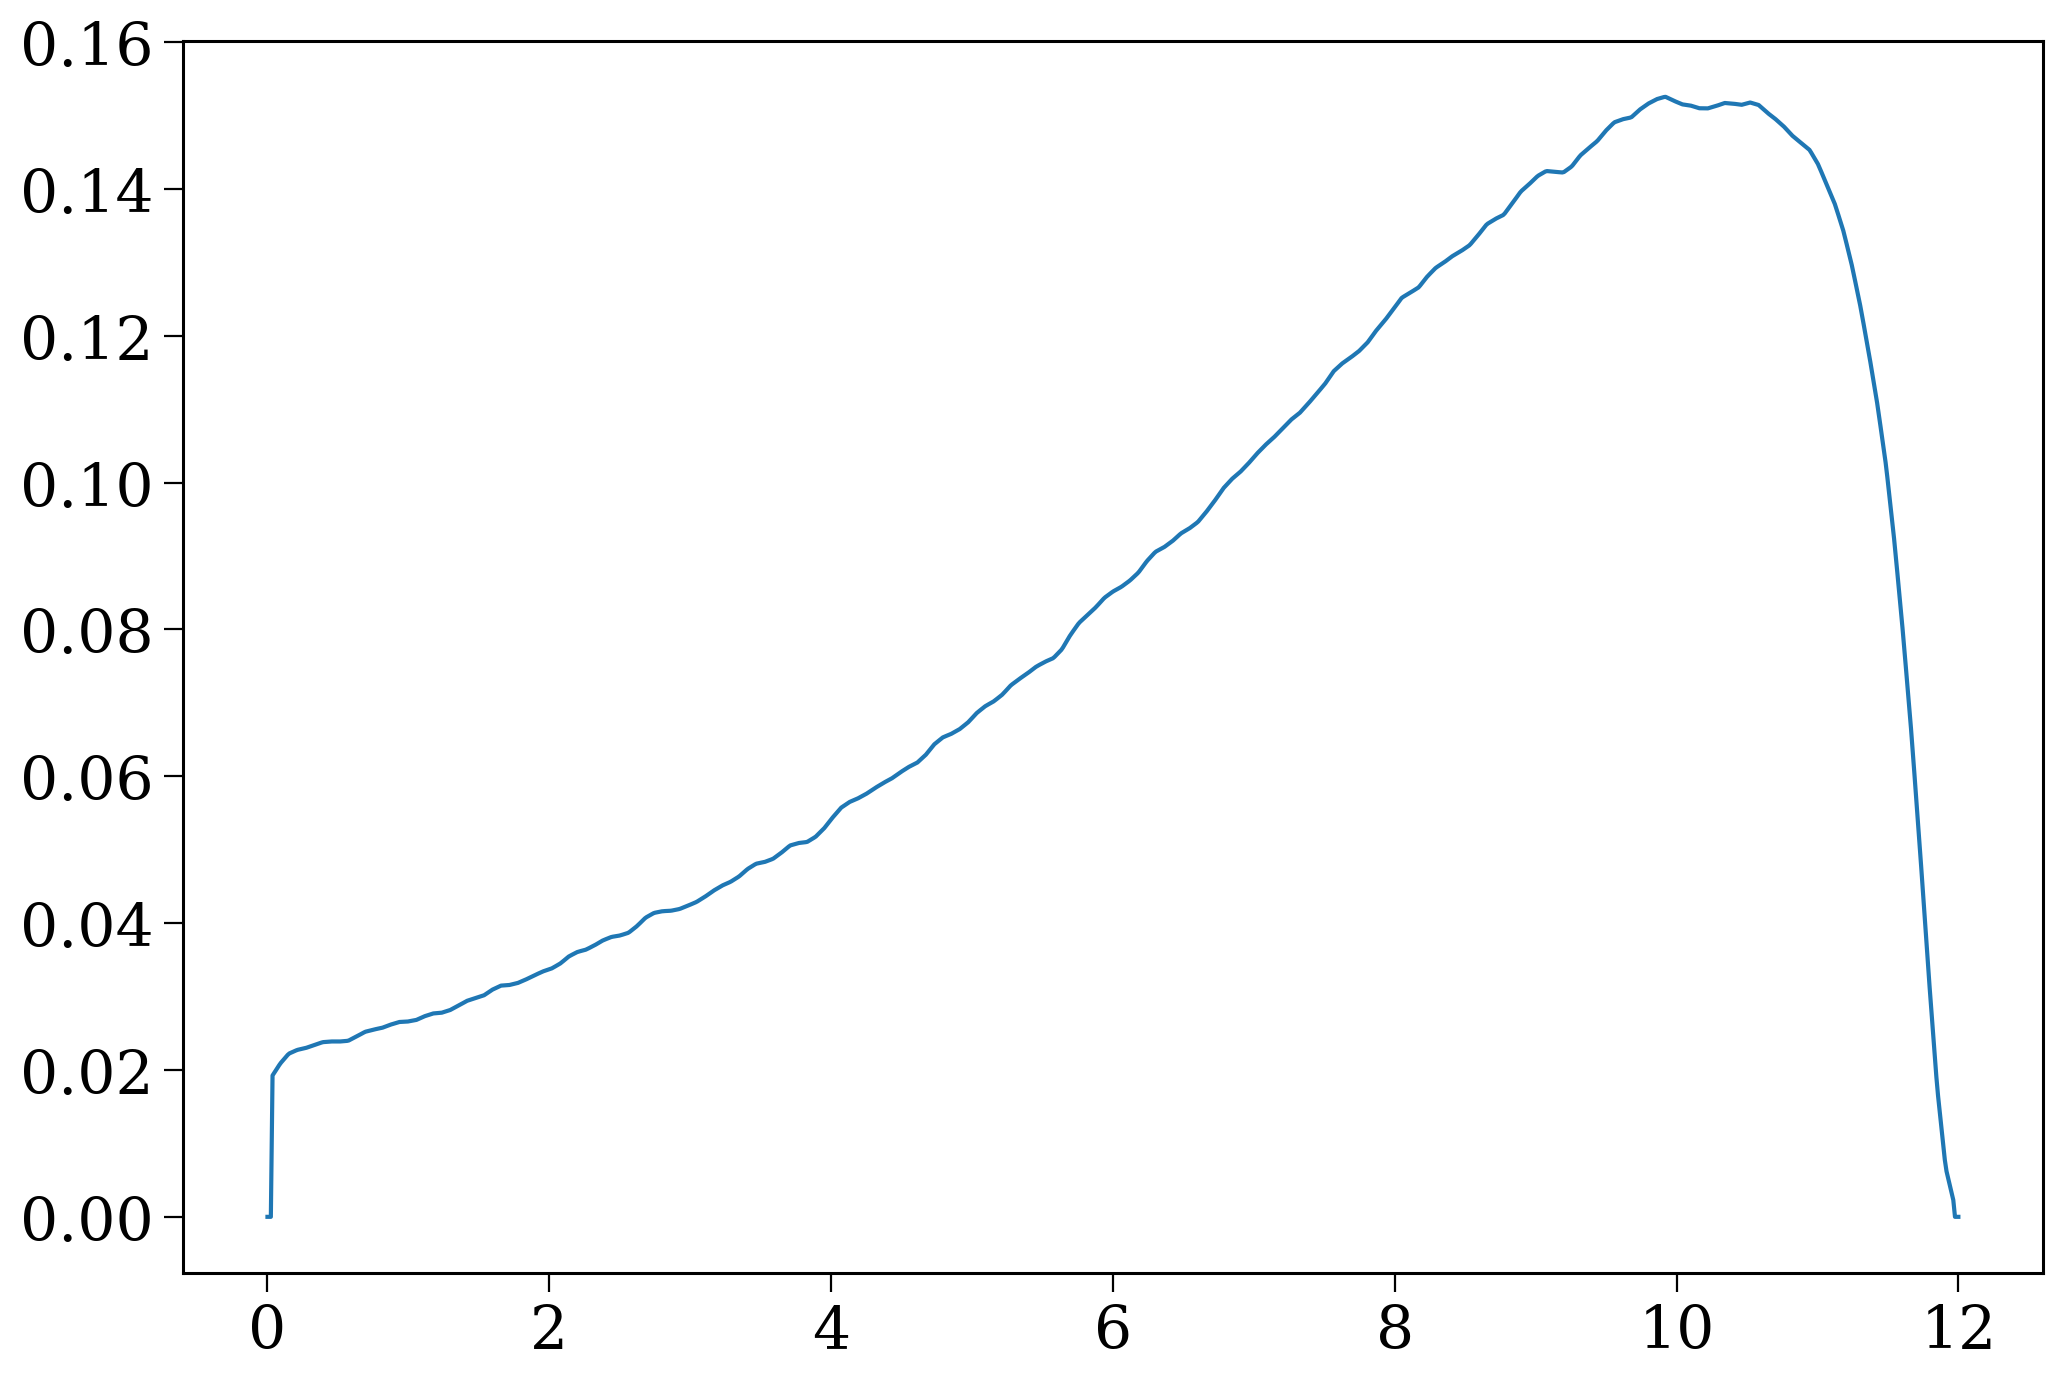

In [ ]:
plt.plot(tau_range, p_of_tau_interp(tau_range))

# plot 

In [51]:
weights = p_of_tau_interp(tau_range)
factors = f_from_tau(tau_range) ** (1 / 4)

mean_factor = np.trapezoid(factors * weights, tau_range) / np.trapezoid(weights, tau_range)
mean_factor

np.float64(1.055257708550218)

In [69]:
cumulative_trapezoid(p_of_f, f_range, initial=0)[-1]

np.float64(0.12499166666666658)

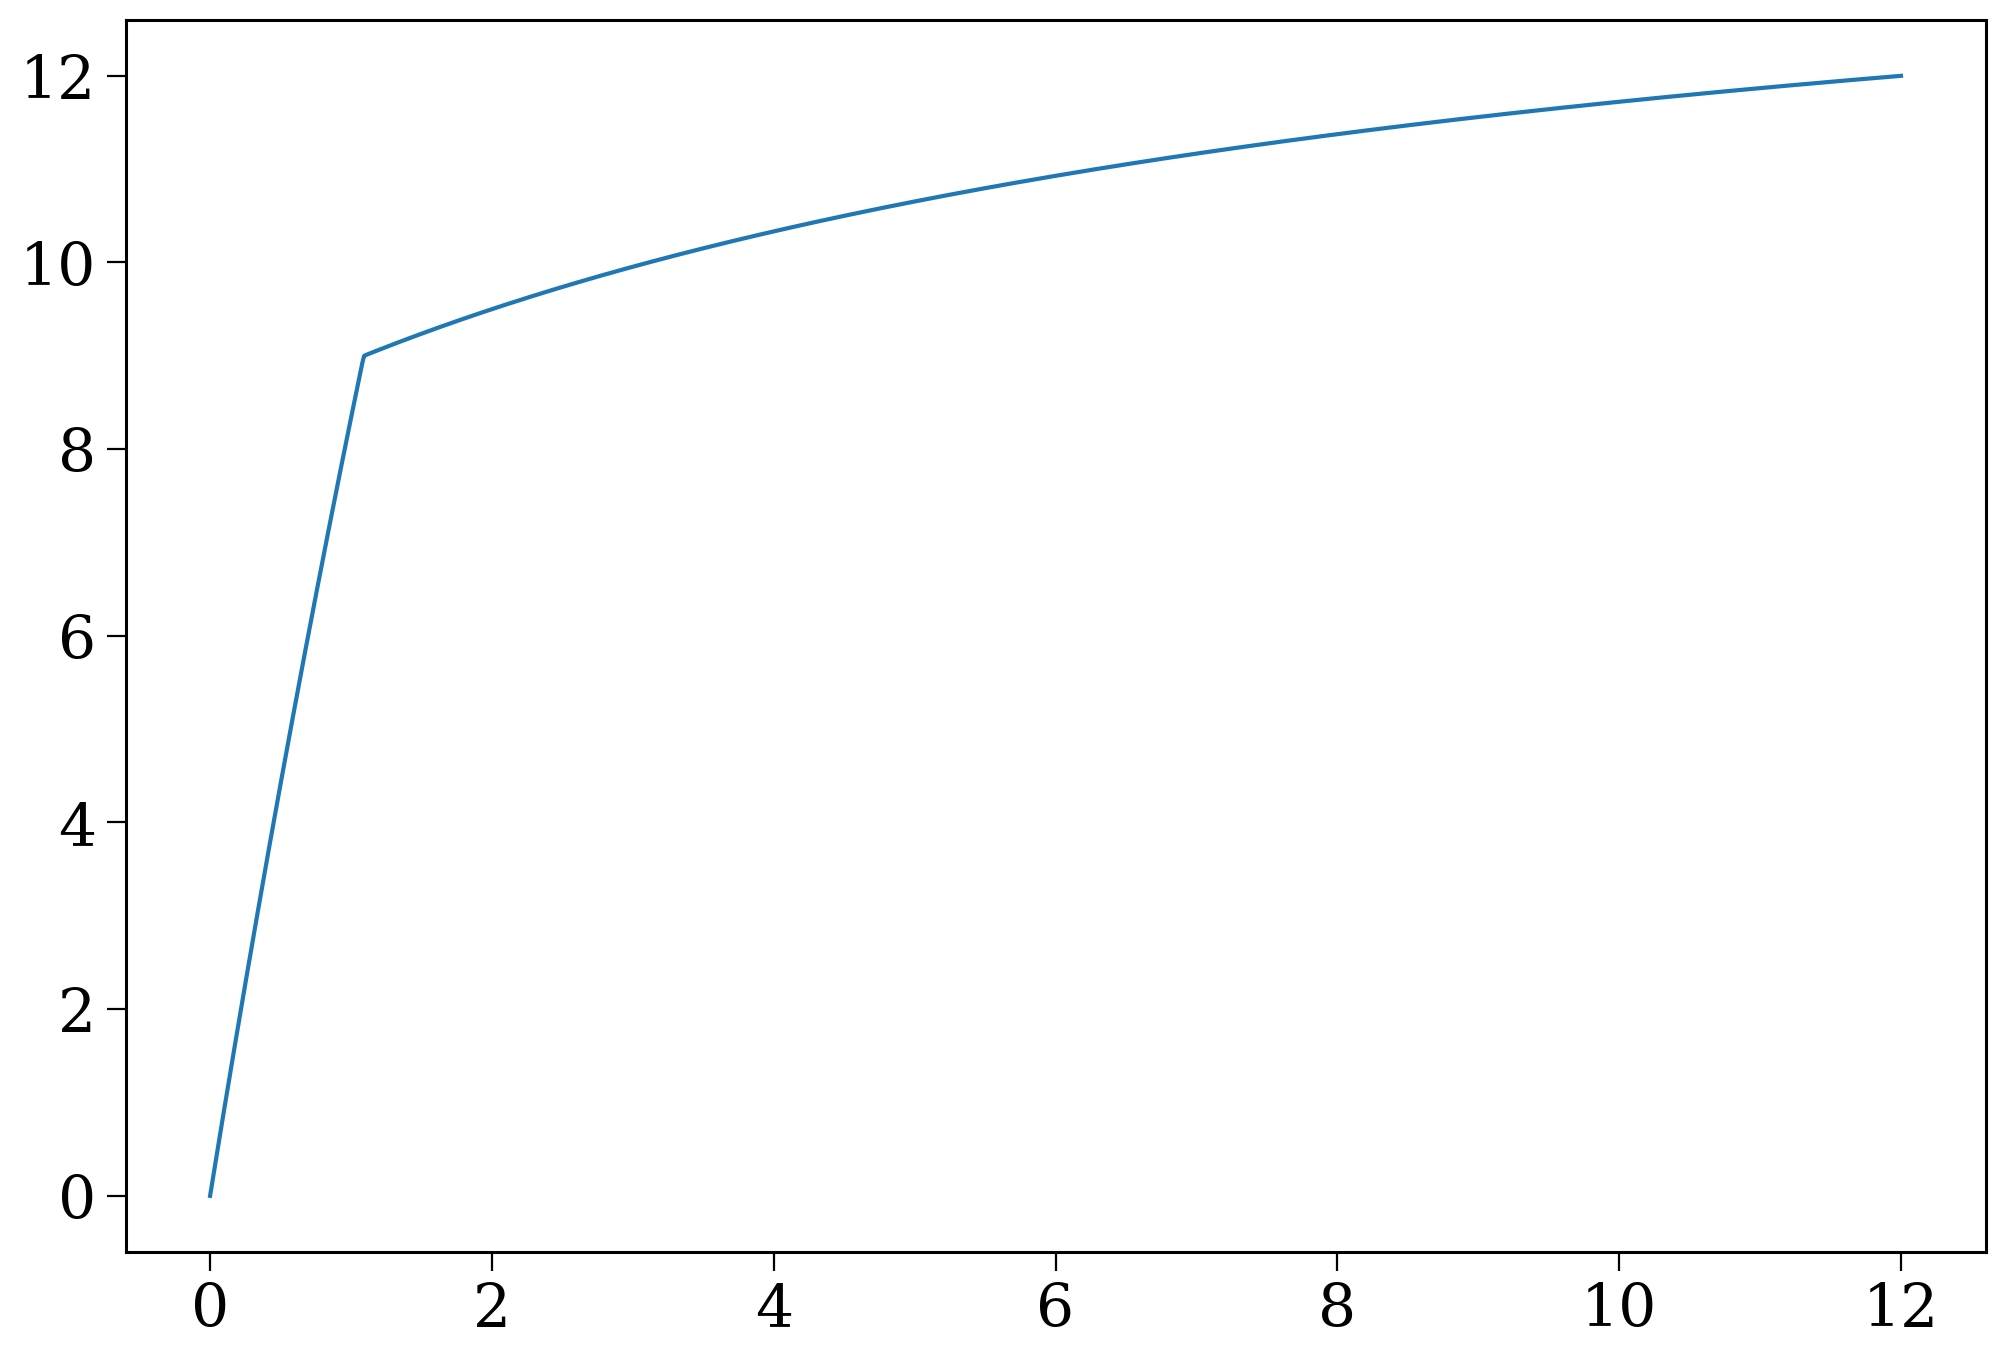

In [83]:
plt.plot(tau_range, tau_from_f(f_range))

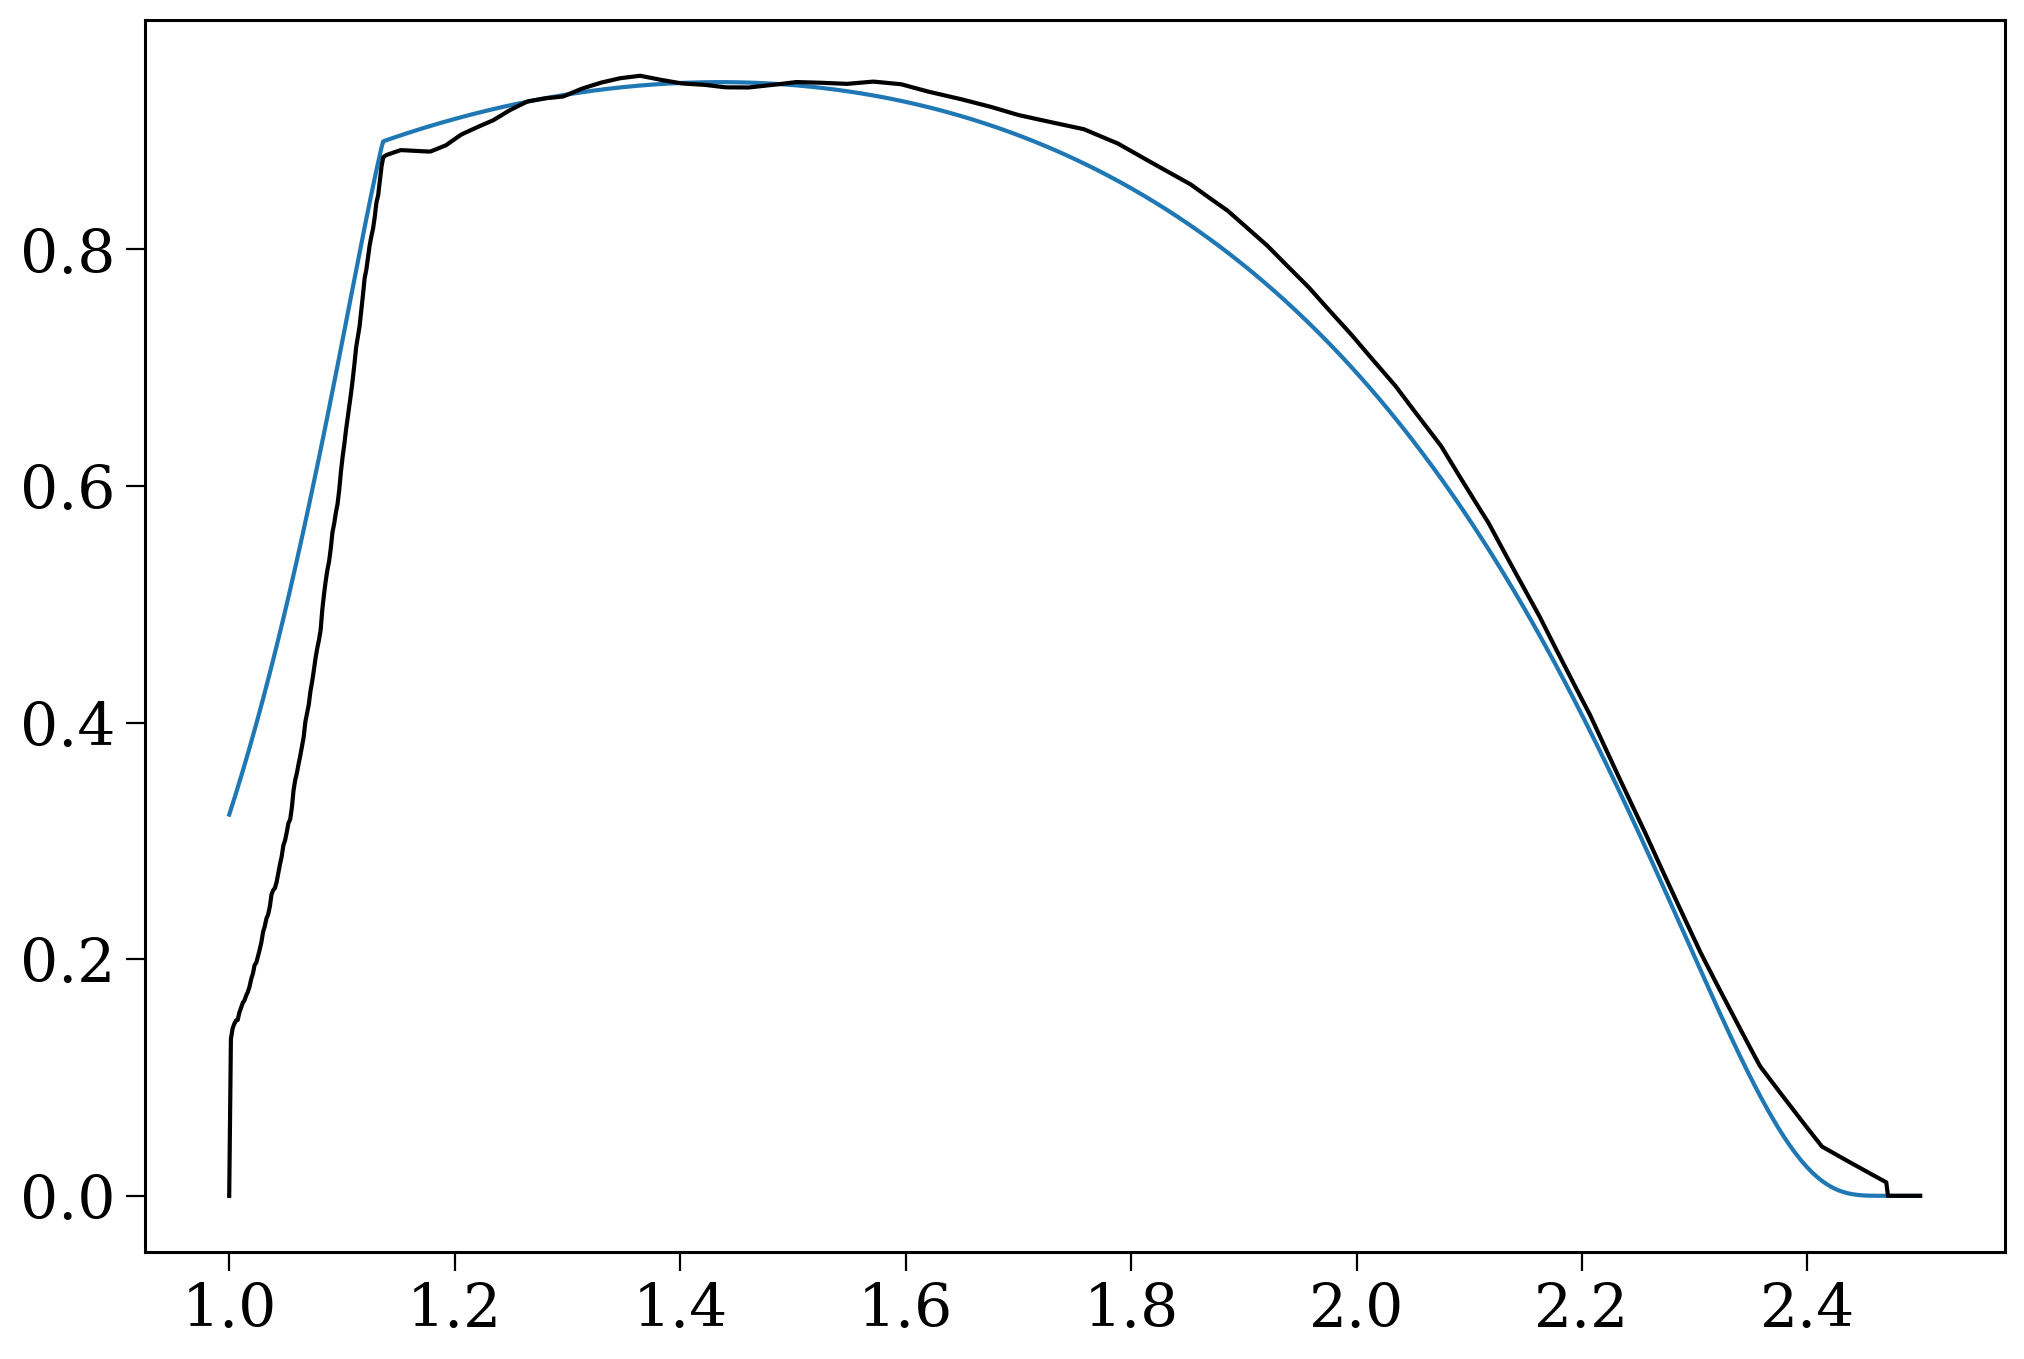

In [79]:
f_range = np.linspace(1, 2.4999, 1000)

p_of_f = p_of_tau(tau_from_f(f_range))
p_of_f_interp = p_of_tau_interp(tau_from_f(f_range))

plt.plot(f_range, p_of_f / np.trapezoid(p_of_f, f_range))
plt.plot(f_range, p_of_f_interp / np.trapezoid(p_of_f_interp, f_range), color="k", label="Interpolated histogram")

In [76]:
np.trapezoid(p_of_f * f_range**(1/4), f_range) / np.trapezoid(p_of_f, f_range)

np.float64(1.1210497030611548)

In [77]:
np.trapezoid(p_of_f_interp * f_range**(1/4), f_range) / np.trapezoid(p_of_f_interp, f_range)

np.float64(1.1247259793633062)

In [53]:
s = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_part0.h5")

In [55]:
bh_prim_nums = s.bin_nums[s.final_bpp["kstar_1"] == 14]
bh_sec_nums = s.bin_nums[s.final_bpp["kstar_2"] == 14]

bh_kicks_prim = s.kick_info.loc[bh_prim_nums][s.kick_info.loc[bh_prim_nums]["star"] == 1]["natal_kick"].values
bh_kicks_sec = s.kick_info.loc[bh_sec_nums][s.kick_info.loc[bh_sec_nums]["star"] == 2]["natal_kick"].values

print(len(bh_prim_nums), len(bh_sec_nums))
print(len(bh_kicks_prim), len(bh_kicks_sec))

bh_times_prim = s.initial_galaxy.tau[s.final_bpp["kstar_1"] == 14]
bh_times_sec = s.initial_galaxy.tau[s.final_bpp["kstar_2"] == 14]

print(len(bh_times_prim), len(bh_times_sec))

bh_times = bh_times_prim.to(u.Gyr).value#np.concatenate([bh_times_prim, bh_times_sec]).to(u.Gyr).value
bh_kicks = bh_kicks_prim#np.concatenate([bh_kicks_prim, bh_kicks_sec])

print(len(bh_times), len(bh_kicks))

22381 29838
22381 28067
22381 29838
22381 22381


In [60]:
1 - (bh_kicks <= 10).sum() / len(bh_kicks)

np.float64(0.8122961440507573)

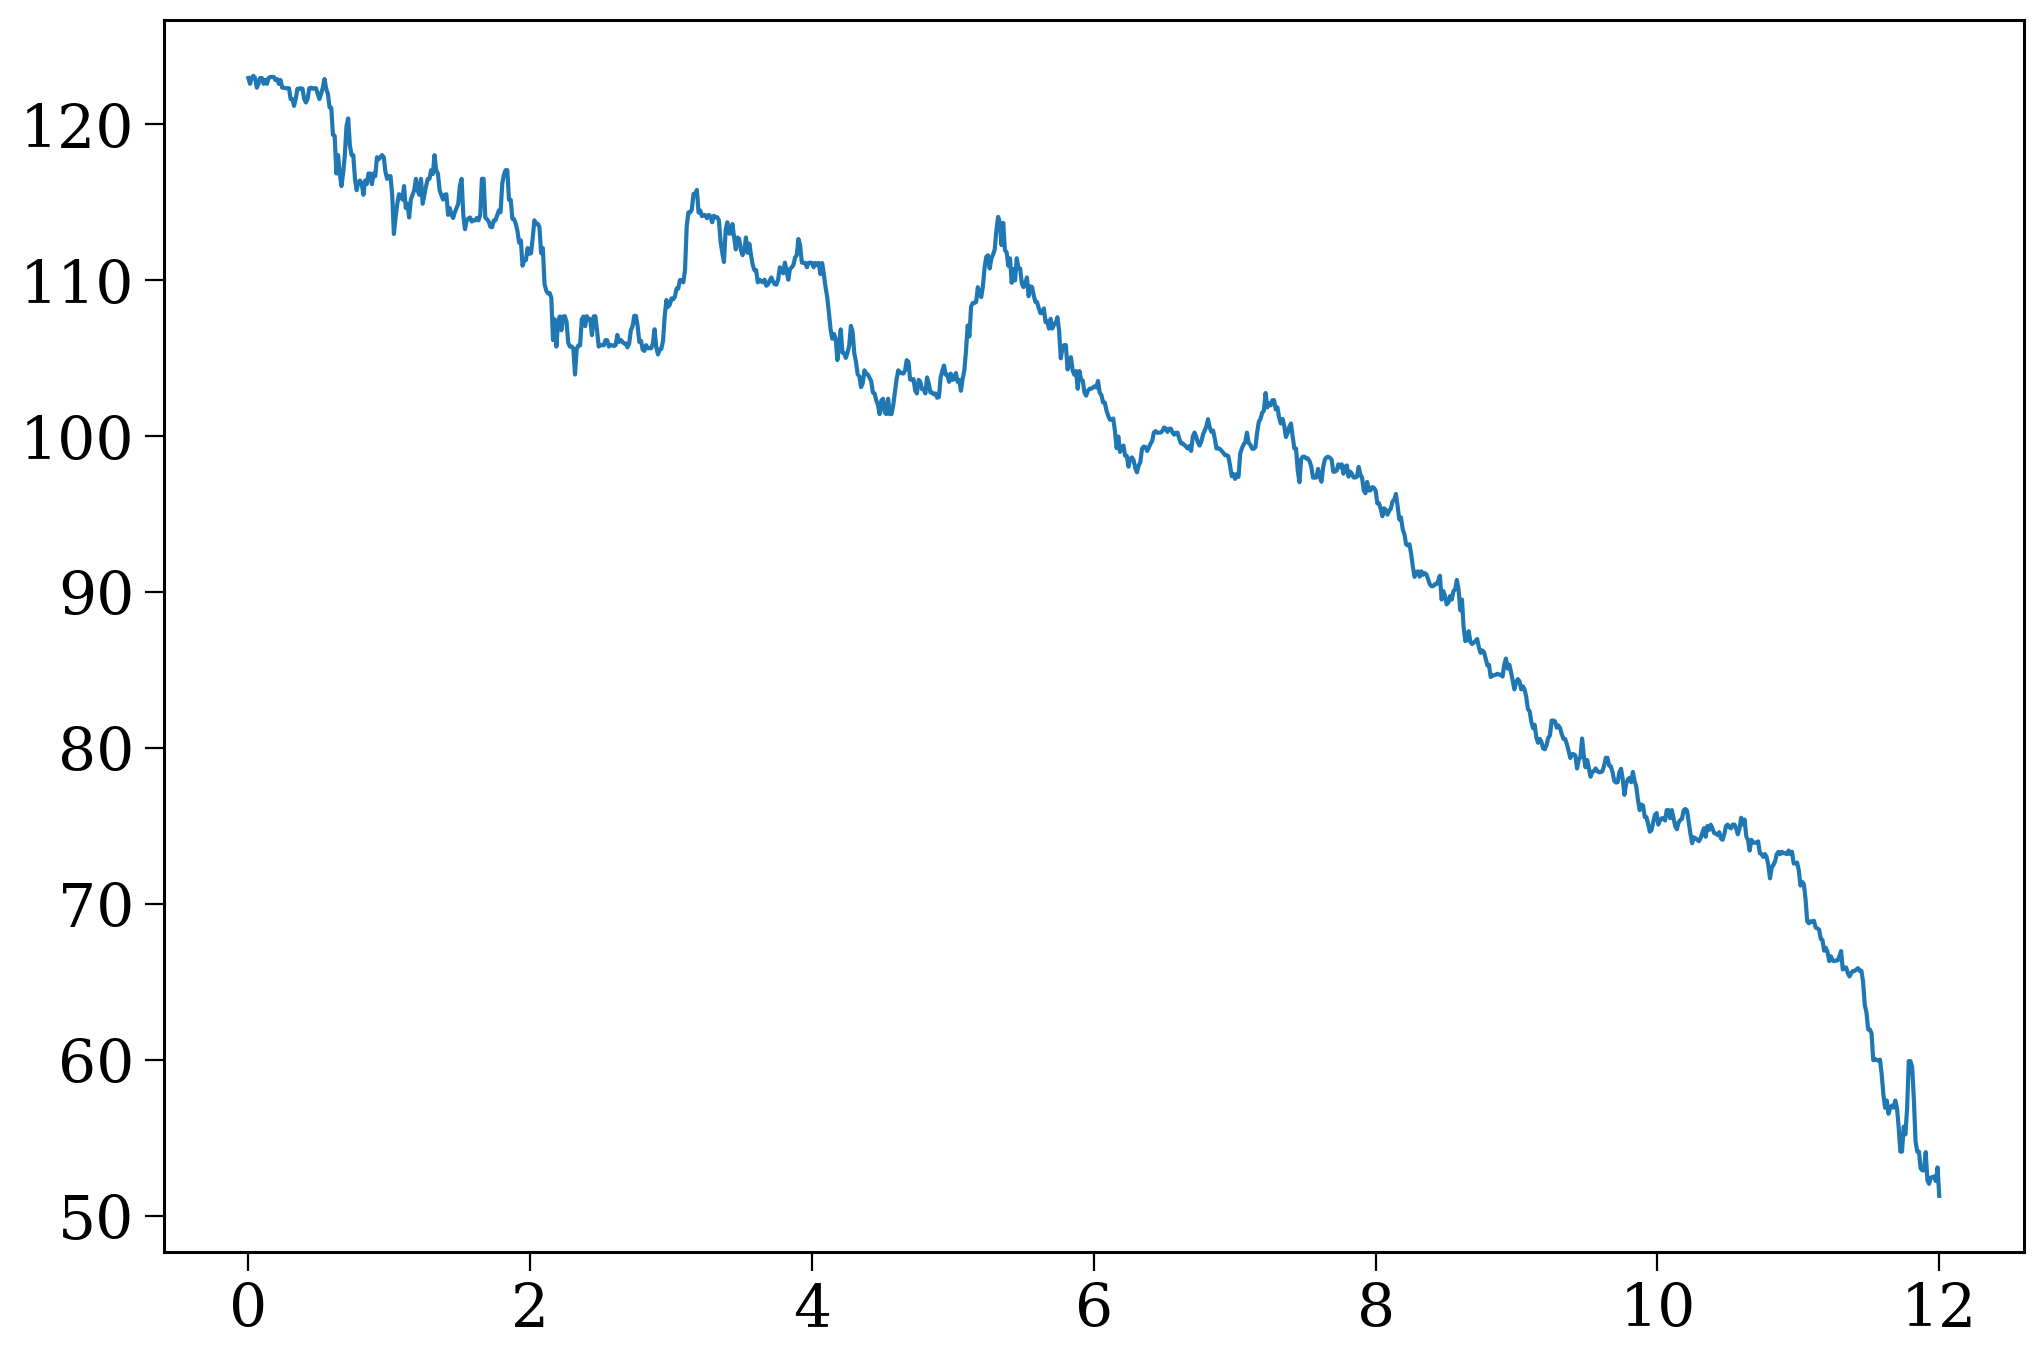

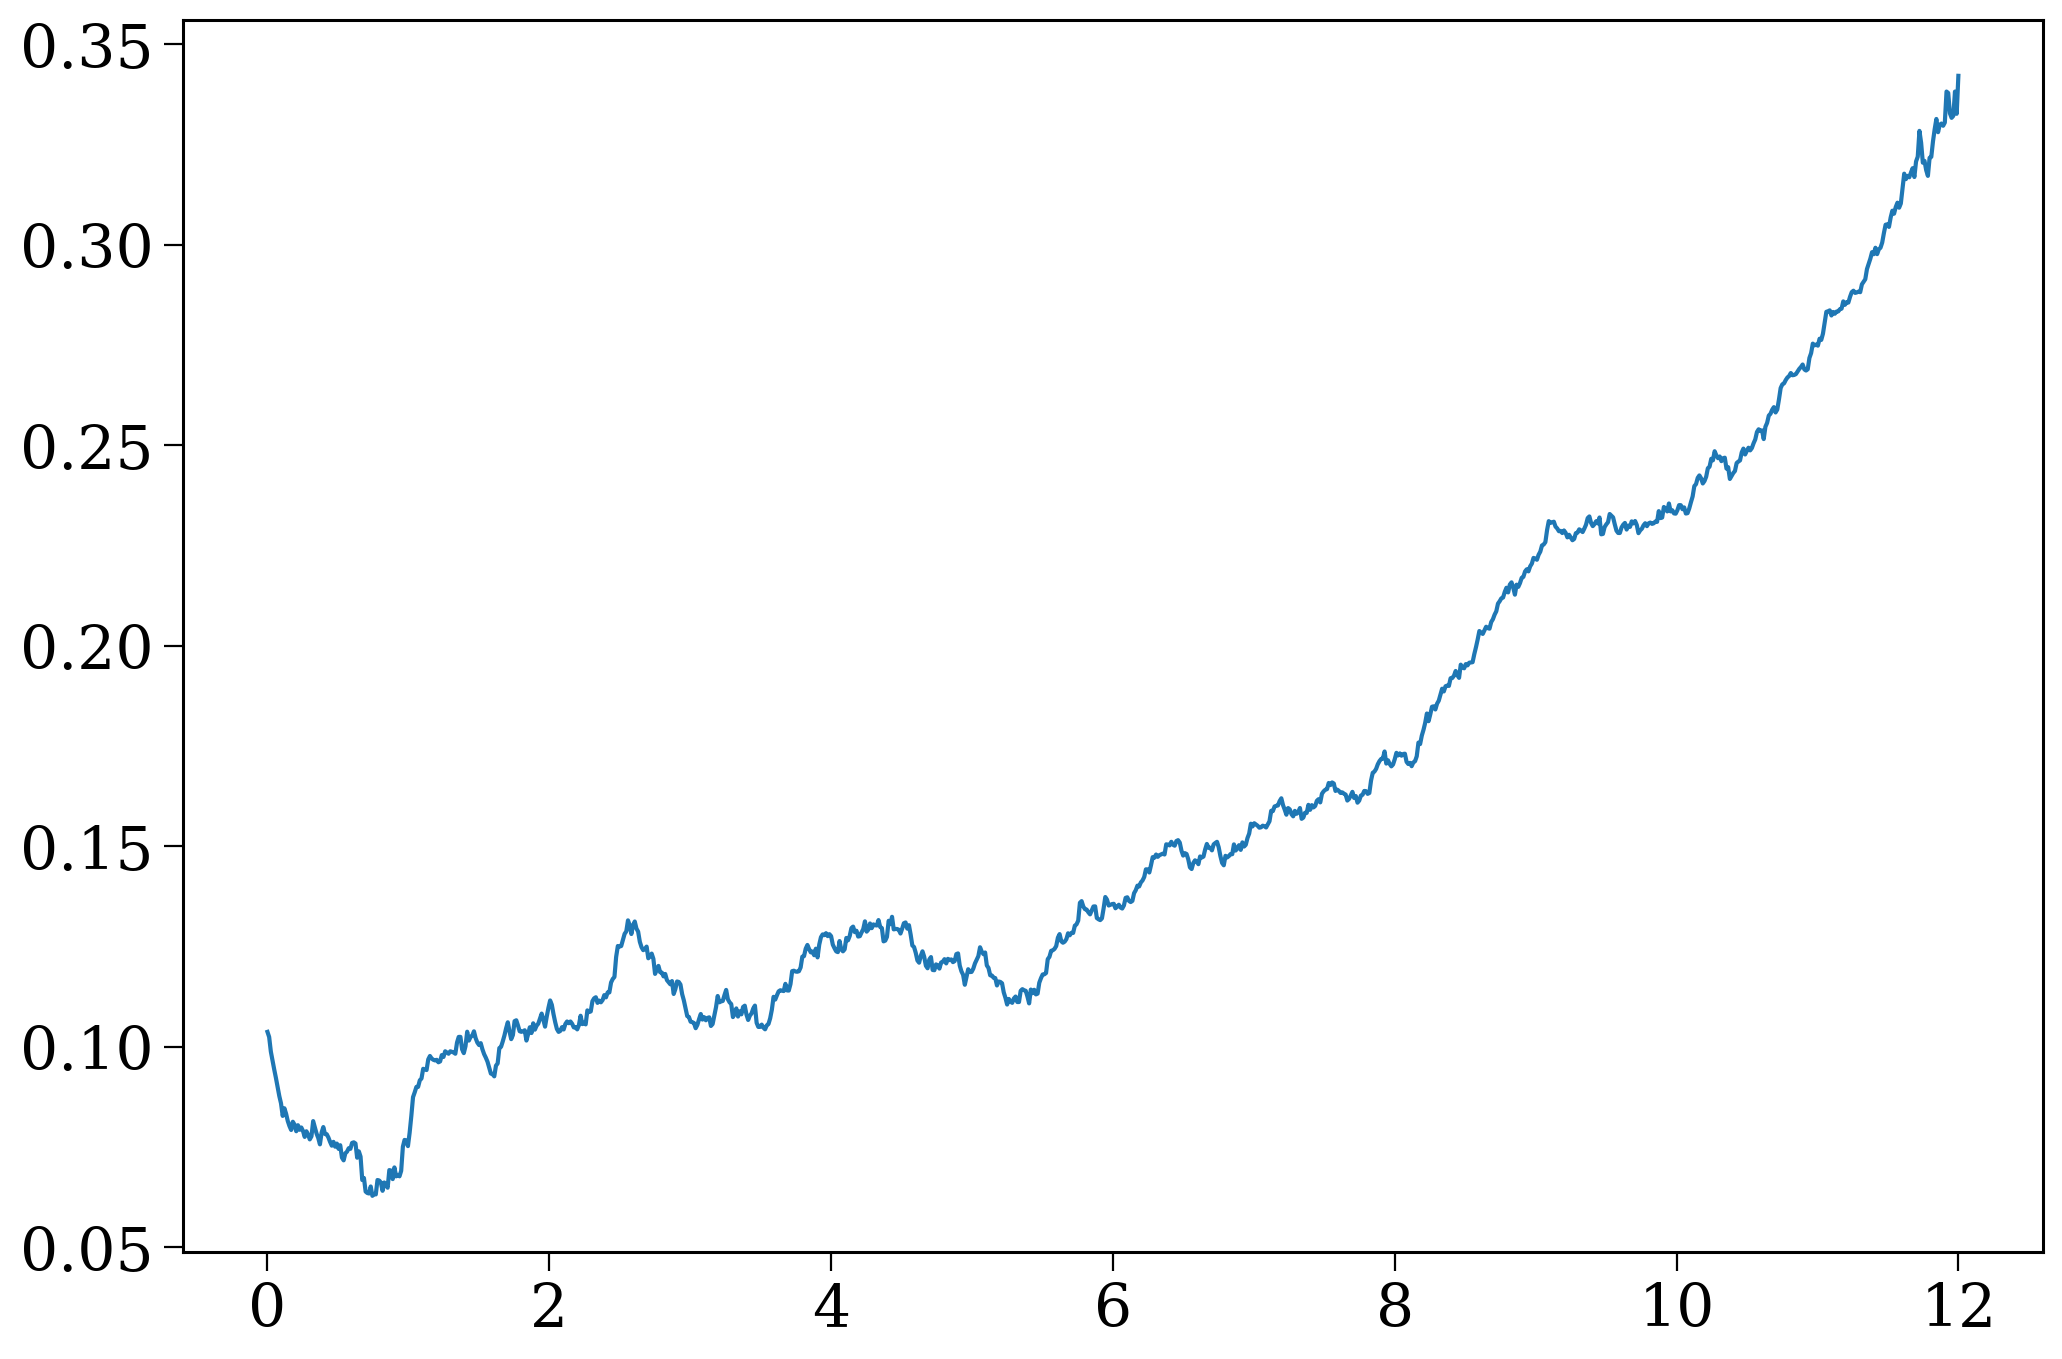

In [58]:
# plot the average kick as a function of time with a moving window
window_width = 1
tau_range = np.linspace(0, 12, 1000)
avg_kicks = []
f_unkicked = []
for tau in tau_range:
    mask = (bh_times > tau - window_width / 2) & (bh_times <= tau + window_width / 2)
    avg_kicks.append(np.median(bh_kicks[mask]))
    f_unkicked.append((bh_kicks[mask] <= 10).sum() / mask.sum())

plt.plot(tau_range, avg_kicks)
plt.show()
plt.plot(tau_range, f_unkicked)

In [41]:
s.kick_info

,star,disrupted,natal_kick,phi,theta,mean_anomaly,delta_vsysx_1,delta_vsysy_1,delta_vsysz_1,vsys_1_total,delta_vsysx_2,delta_vsysy_2,delta_vsysz_2,vsys_2_total,theta_euler,phi_euler,psi_euler,randomseed,bin_num
0,1.0,1.0,166.228388,51.999736,117.155424,0.000000,-46.709038,91.060145,130.989286,166.228388,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.948990e+09,0.0
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0
2,1.0,1.0,311.113656,29.203434,217.205458,159.422361,-216.513713,-164.952866,151.789468,311.653138,1.898447,5.990459,0.007518,6.284088,34.503224,147.609022,144.845681,-1.084200e+08,2.0
2,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.0
3,1.0,1.0,418.300585,10.643220,346.218274,0.000000,399.268706,-97.934787,77.257088,418.300585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.535629e+08,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317825,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,317825.0
317826,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,317826.0
317826,2.0,1.0,60.261837,-58.764241,241.156275,0.000000,0.000000,0.000000,0.000000,0.000000,-15.075418,-27.372582,-51.526328,60.261837,0.000000,0.000000,0.000000,-1.188735e+09,317826.0
317828,1.0,1.0,205.532977,12.237845,218.529053,0.000000,-157.133180,-125.119517,43.566899,205.532977,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.332179e+07,317828.0


# Detailed orbits exploration

In [83]:
static_pop = helpers.load_distributed_pop(
    base_path='/mnt/ceph/users/twagg/underworld/sims/',
    sim_name="fiducial",
    parts=5,
    label="Static",
    colour="#333"
)
evolving_pop = helpers.load_distributed_pop(
    base_path='/mnt/ceph/users/twagg/underworld/sims/',
    sim_name="time-evolving-pot",
    parts=5,
    label="Time-evolving",
    colour=constants.FILE_TO_COLOUR["time-evolving-pot"]
)

Loading distributed population Static from 5 parts
   loaded part 1/5 of Static with 163572 binaries
   loaded part 2/5 of Static with 173171 binaries
   loaded part 3/5 of Static with 167215 binaries
   loaded part 4/5 of Static with 164109 binaries
   loaded part 5/5 of Static with 166509 binaries
Loading distributed population Time-evolving from 5 parts
   loaded part 1/5 of Time-evolving with 163571 binaries
   loaded part 2/5 of Time-evolving with 173171 binaries
   loaded part 3/5 of Time-evolving with 167215 binaries
   loaded part 4/5 of Time-evolving with 164109 binaries
   loaded part 5/5 of Time-evolving with 166509 binaries


In [84]:
reload(helpers)
static_kick_stats = helpers.get_kick_stats(static_pop)
evolving_kick_stats = helpers.get_kick_stats(evolving_pop)

In [85]:
bh_times = static_pop.initial_galaxy.tau[np.isin(static_pop.bin_nums, static_kick_stats["bin_num"])]
bh_time_df = pd.Series(bh_times.value, index=static_pop.bin_nums[np.isin(static_pop.bin_nums, static_kick_stats["bin_num"])], name="bh_time")

In [86]:
static_kick_stats["bh_form_tau"] = bh_time_df.loc[static_kick_stats["bin_num"]].values
static_kick_stats.index = static_kick_stats["bin_num"].values

In [87]:
window_size = 0.3
bins = np.arange(0, 12 + window_size, window_size)
bin_centers = bins[:-1] + window_size / 2
kick = static_kick_stats["delta_v"].copy()
bin_medians = [np.median(kick[(static_kick_stats["bh_form_tau"] >= bins[i]) & (static_kick_stats["bh_form_tau"] < bins[i+1])]) for i in range(len(bins)-1)]

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



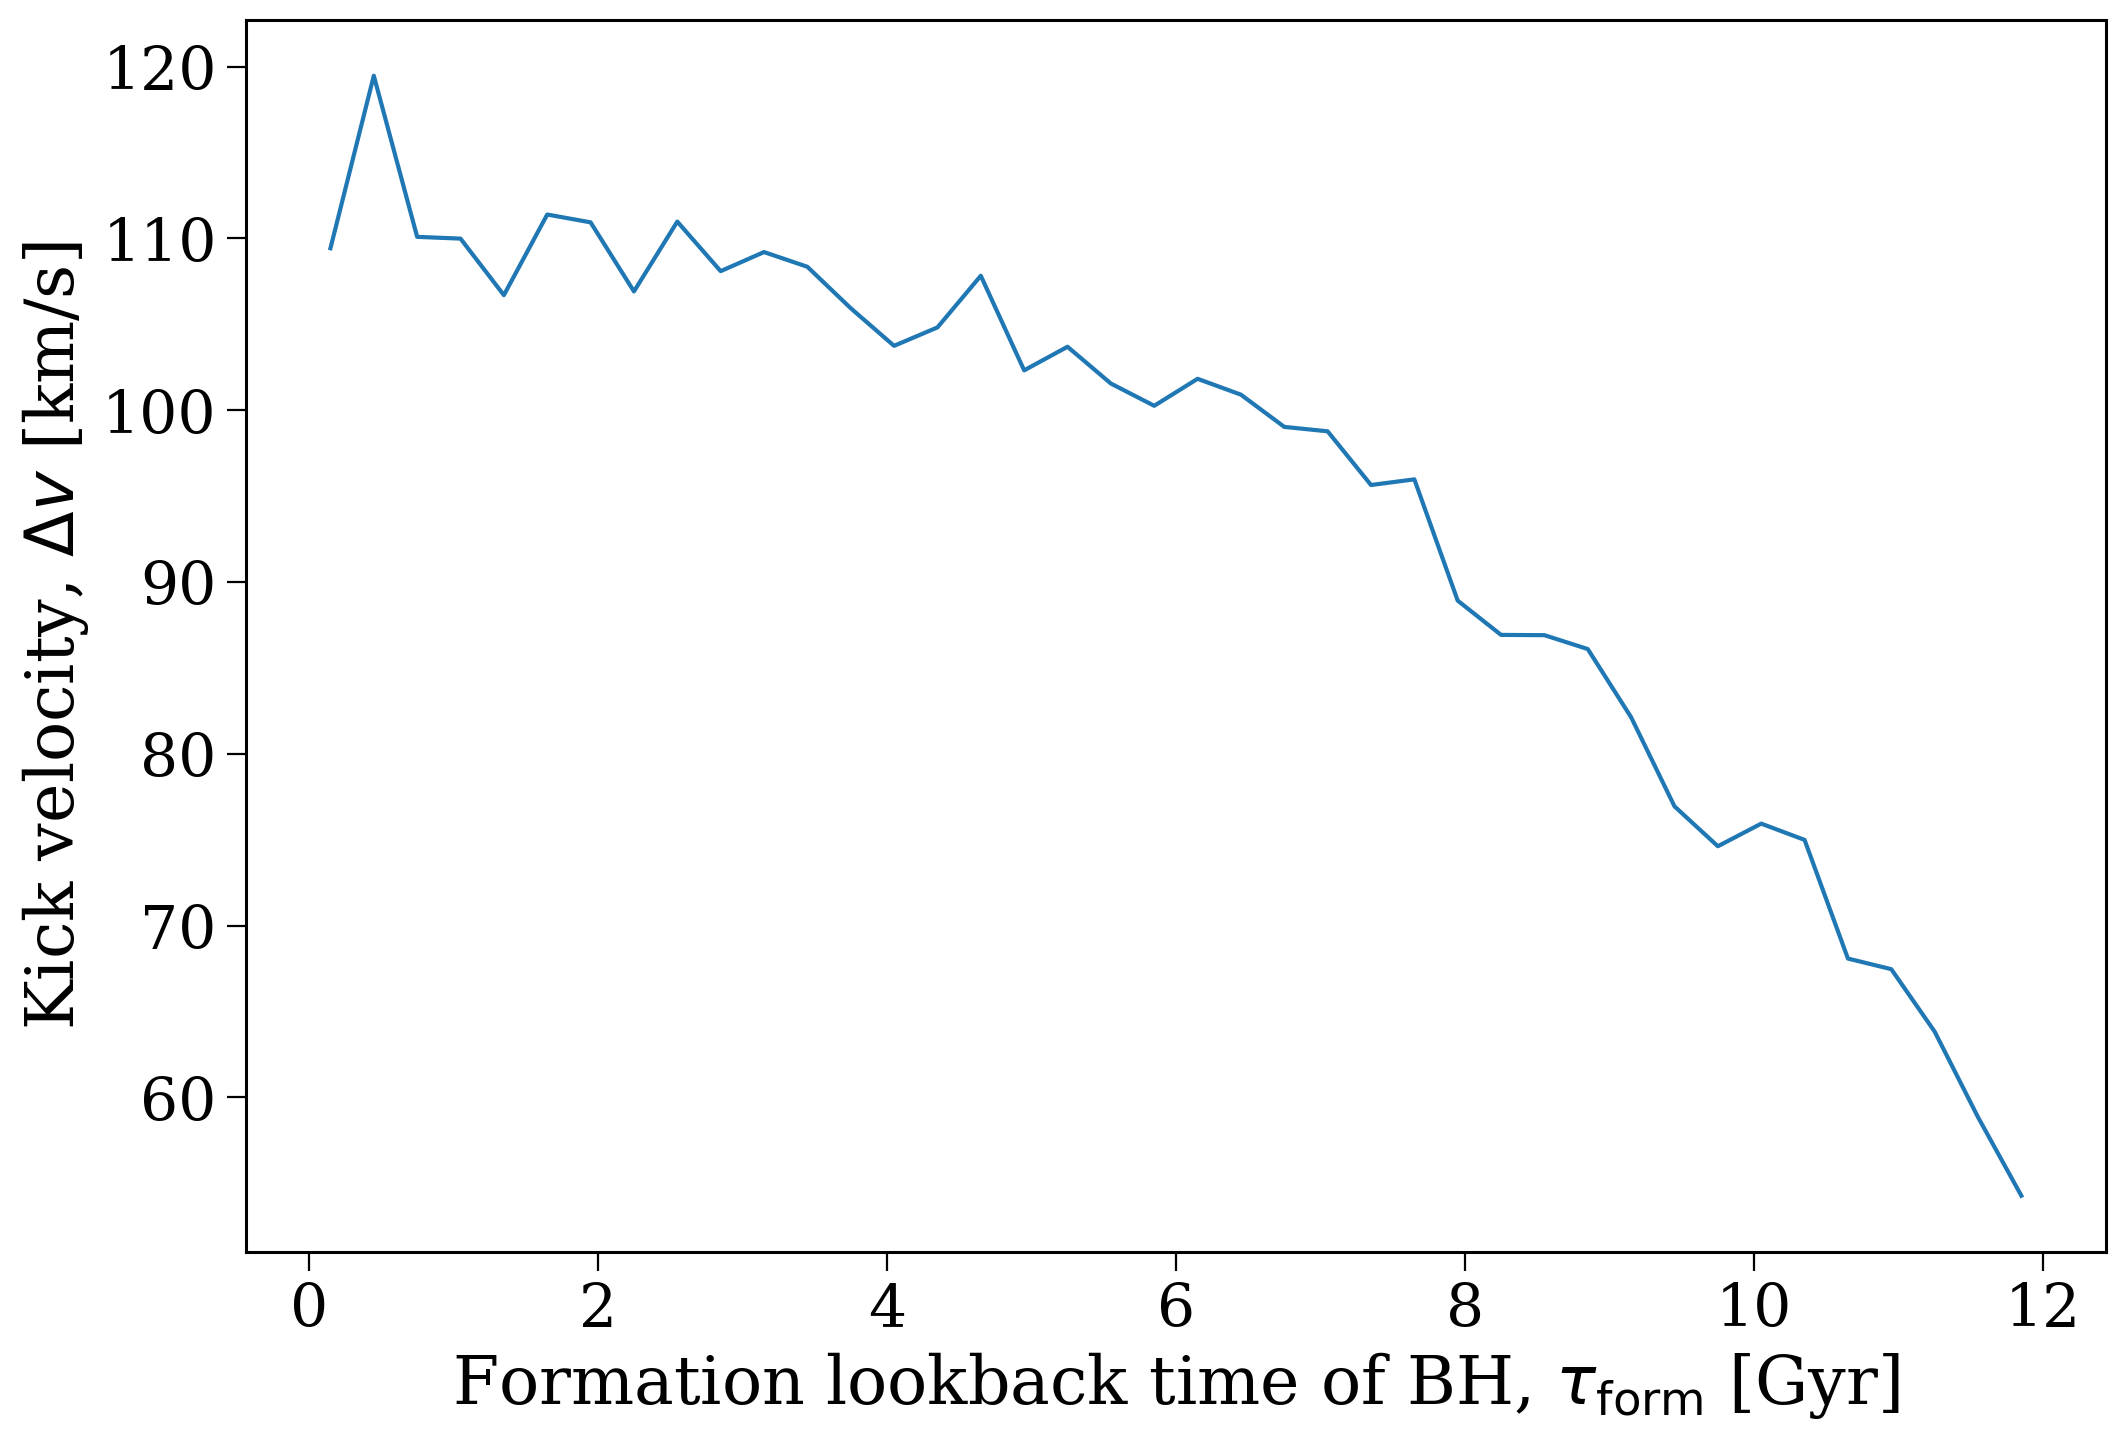

In [88]:
plt.plot(bin_centers, bin_medians, label="Binned median")
plt.xlabel(r"Formation lookback time of BH, $\tau_\mathrm{form}$ [Gyr]")
plt.ylabel(r"Kick velocity, $\Delta v$ [km/s]")
plt.show()

In [89]:
bh_nums = static_kick_stats["bin_num"].values
random_bh_subset = np.random.choice(np.unique(bh_nums), size=1000, replace=False)
smol_pops = [static_pop[random_bh_subset], evolving_pop[random_bh_subset]]
for smol in smol_pops:
    smol.store_entire_orbits = True
    smol.processes = 32
    smol.perform_galactic_evolution()

Integrating orbits: 100%|██████████| 1508/1508 [00:02<00:00, 574.38it/s]


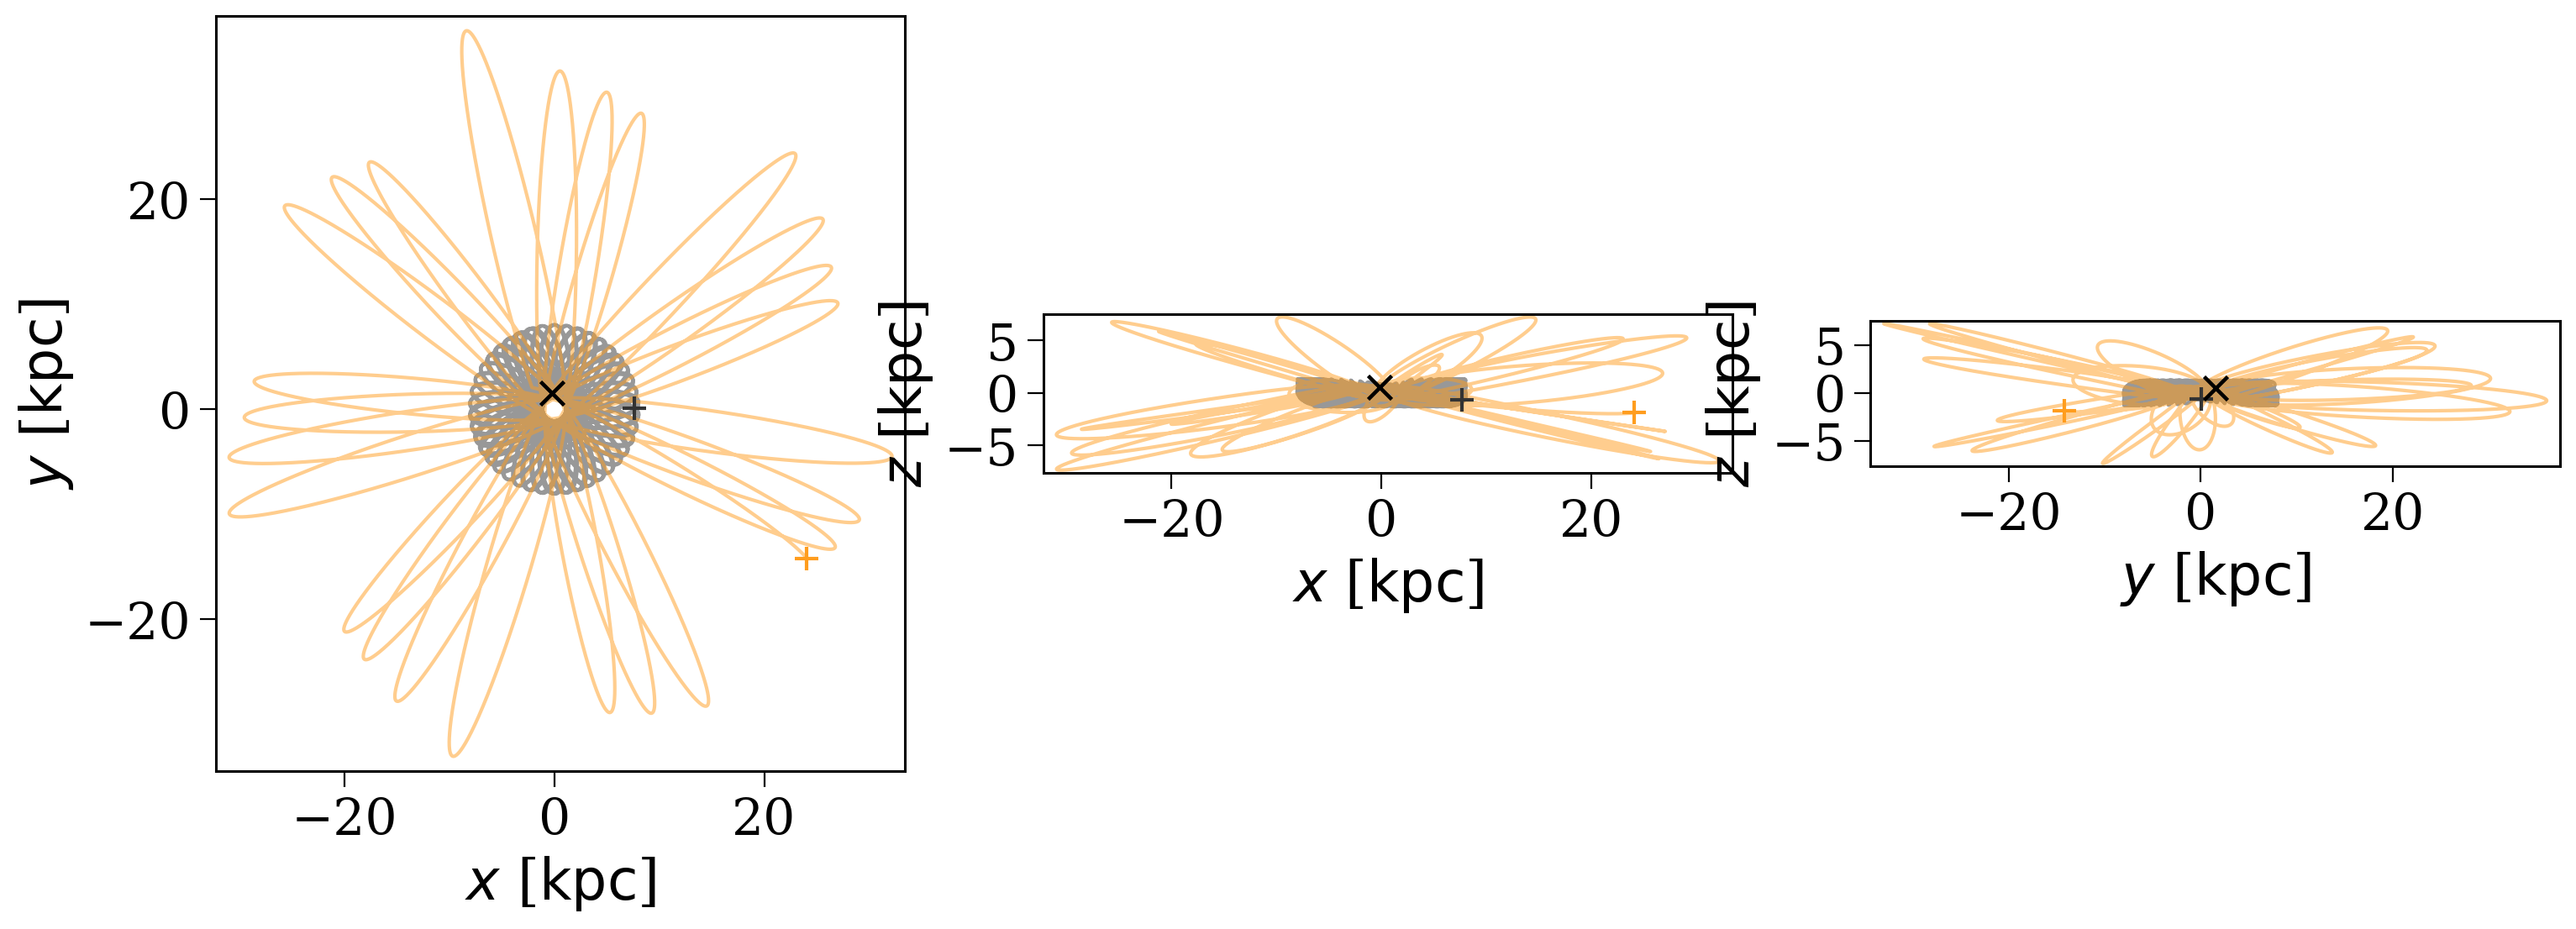

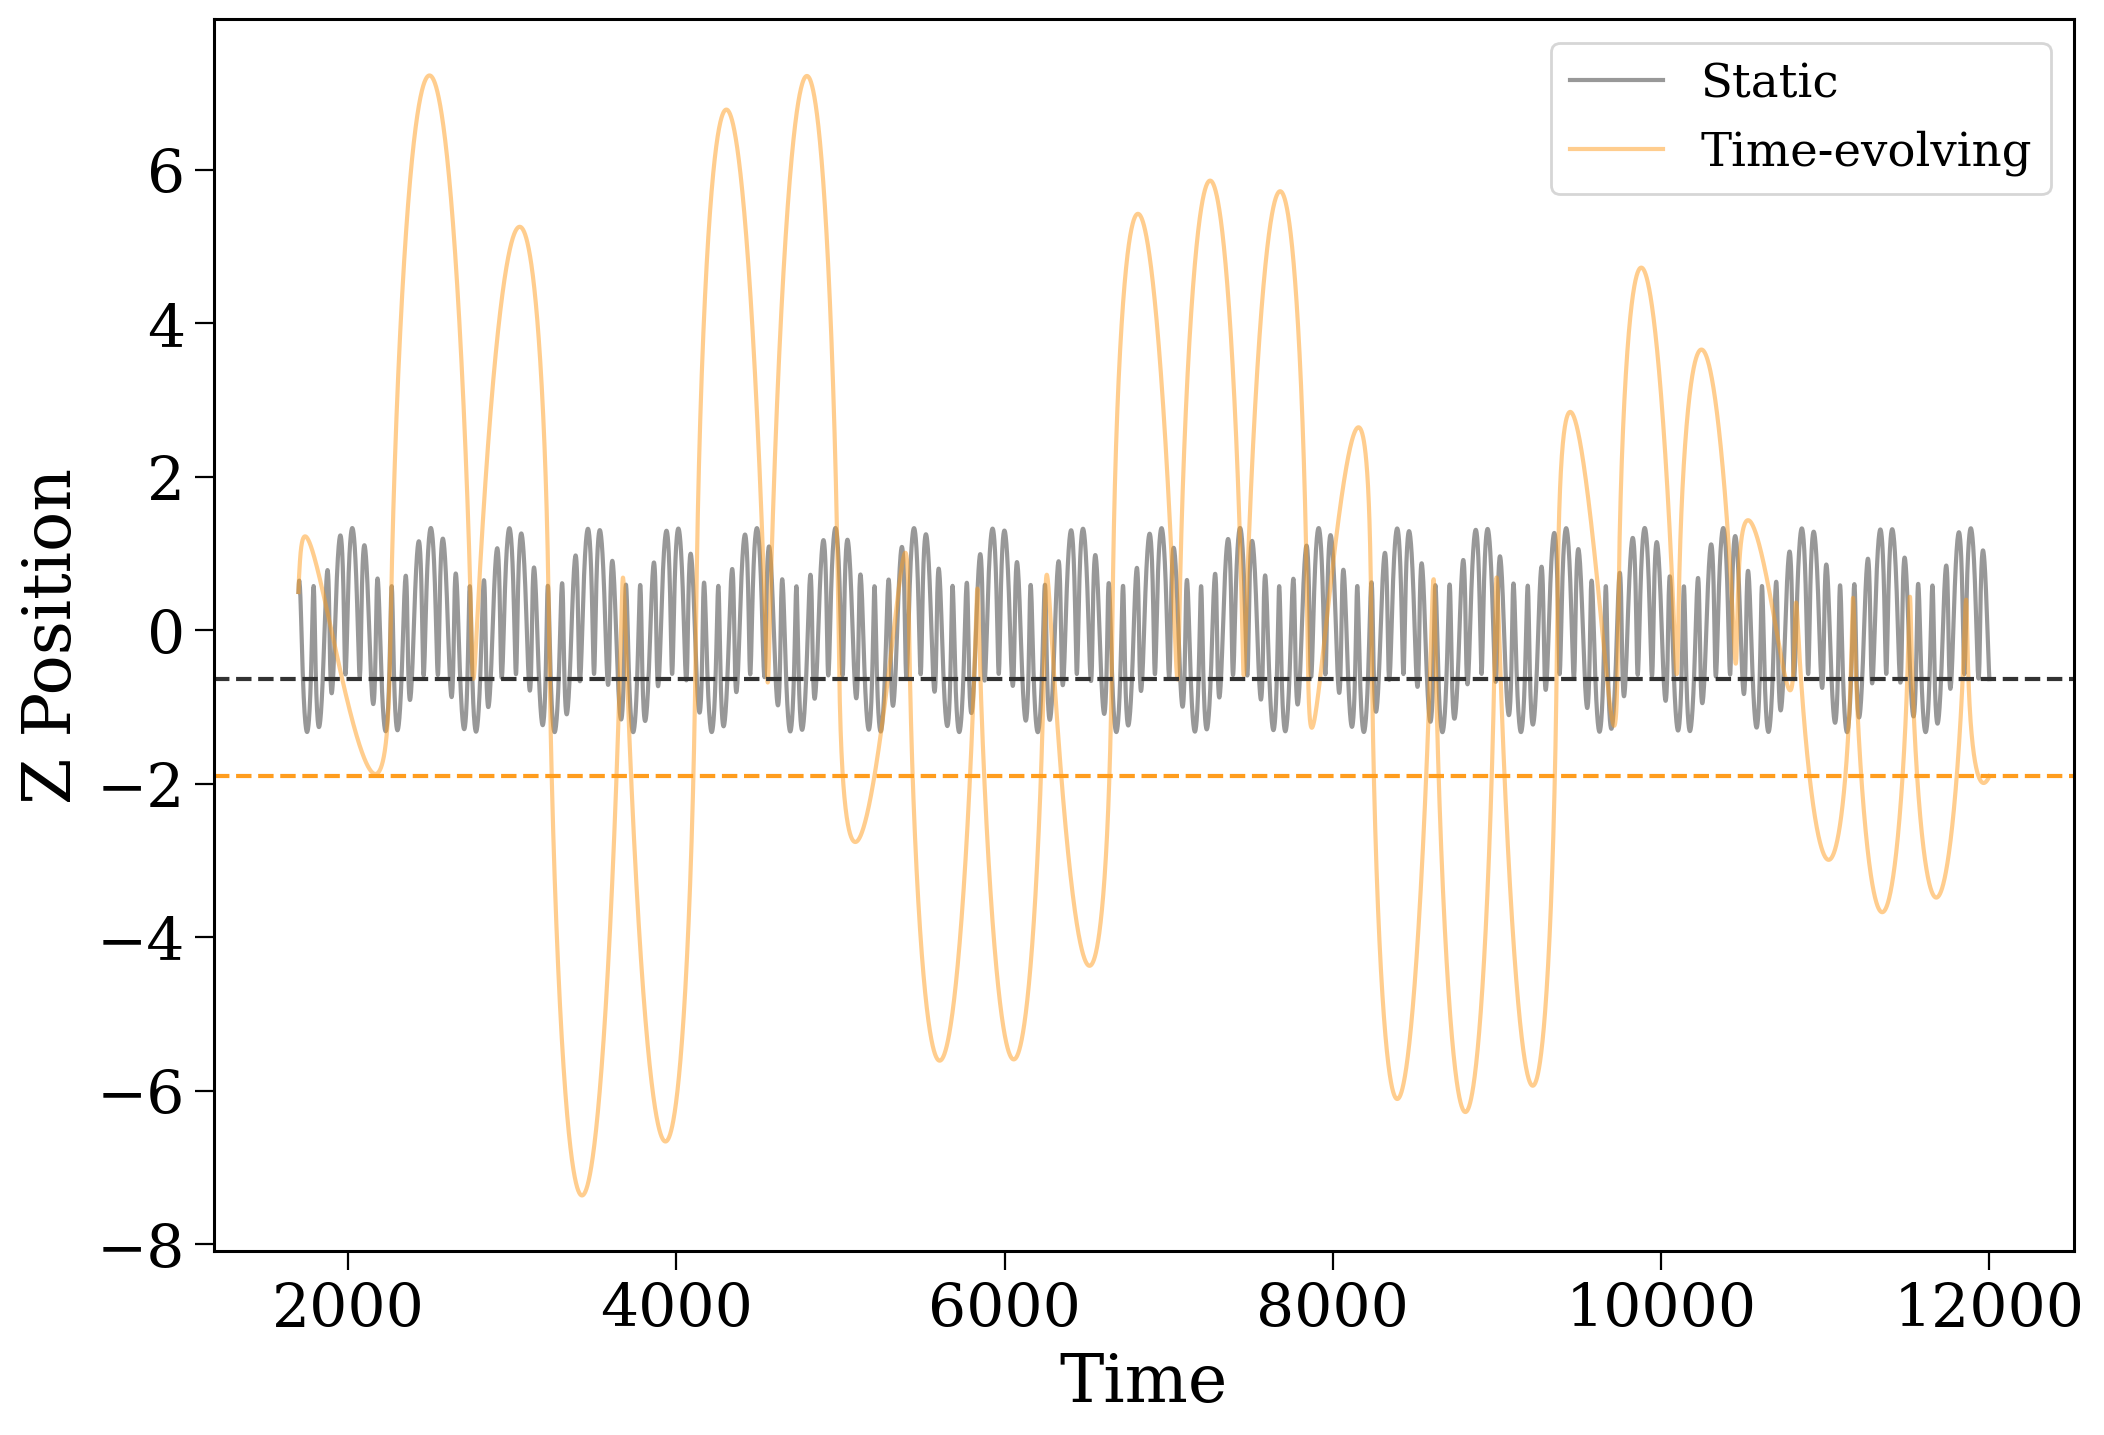

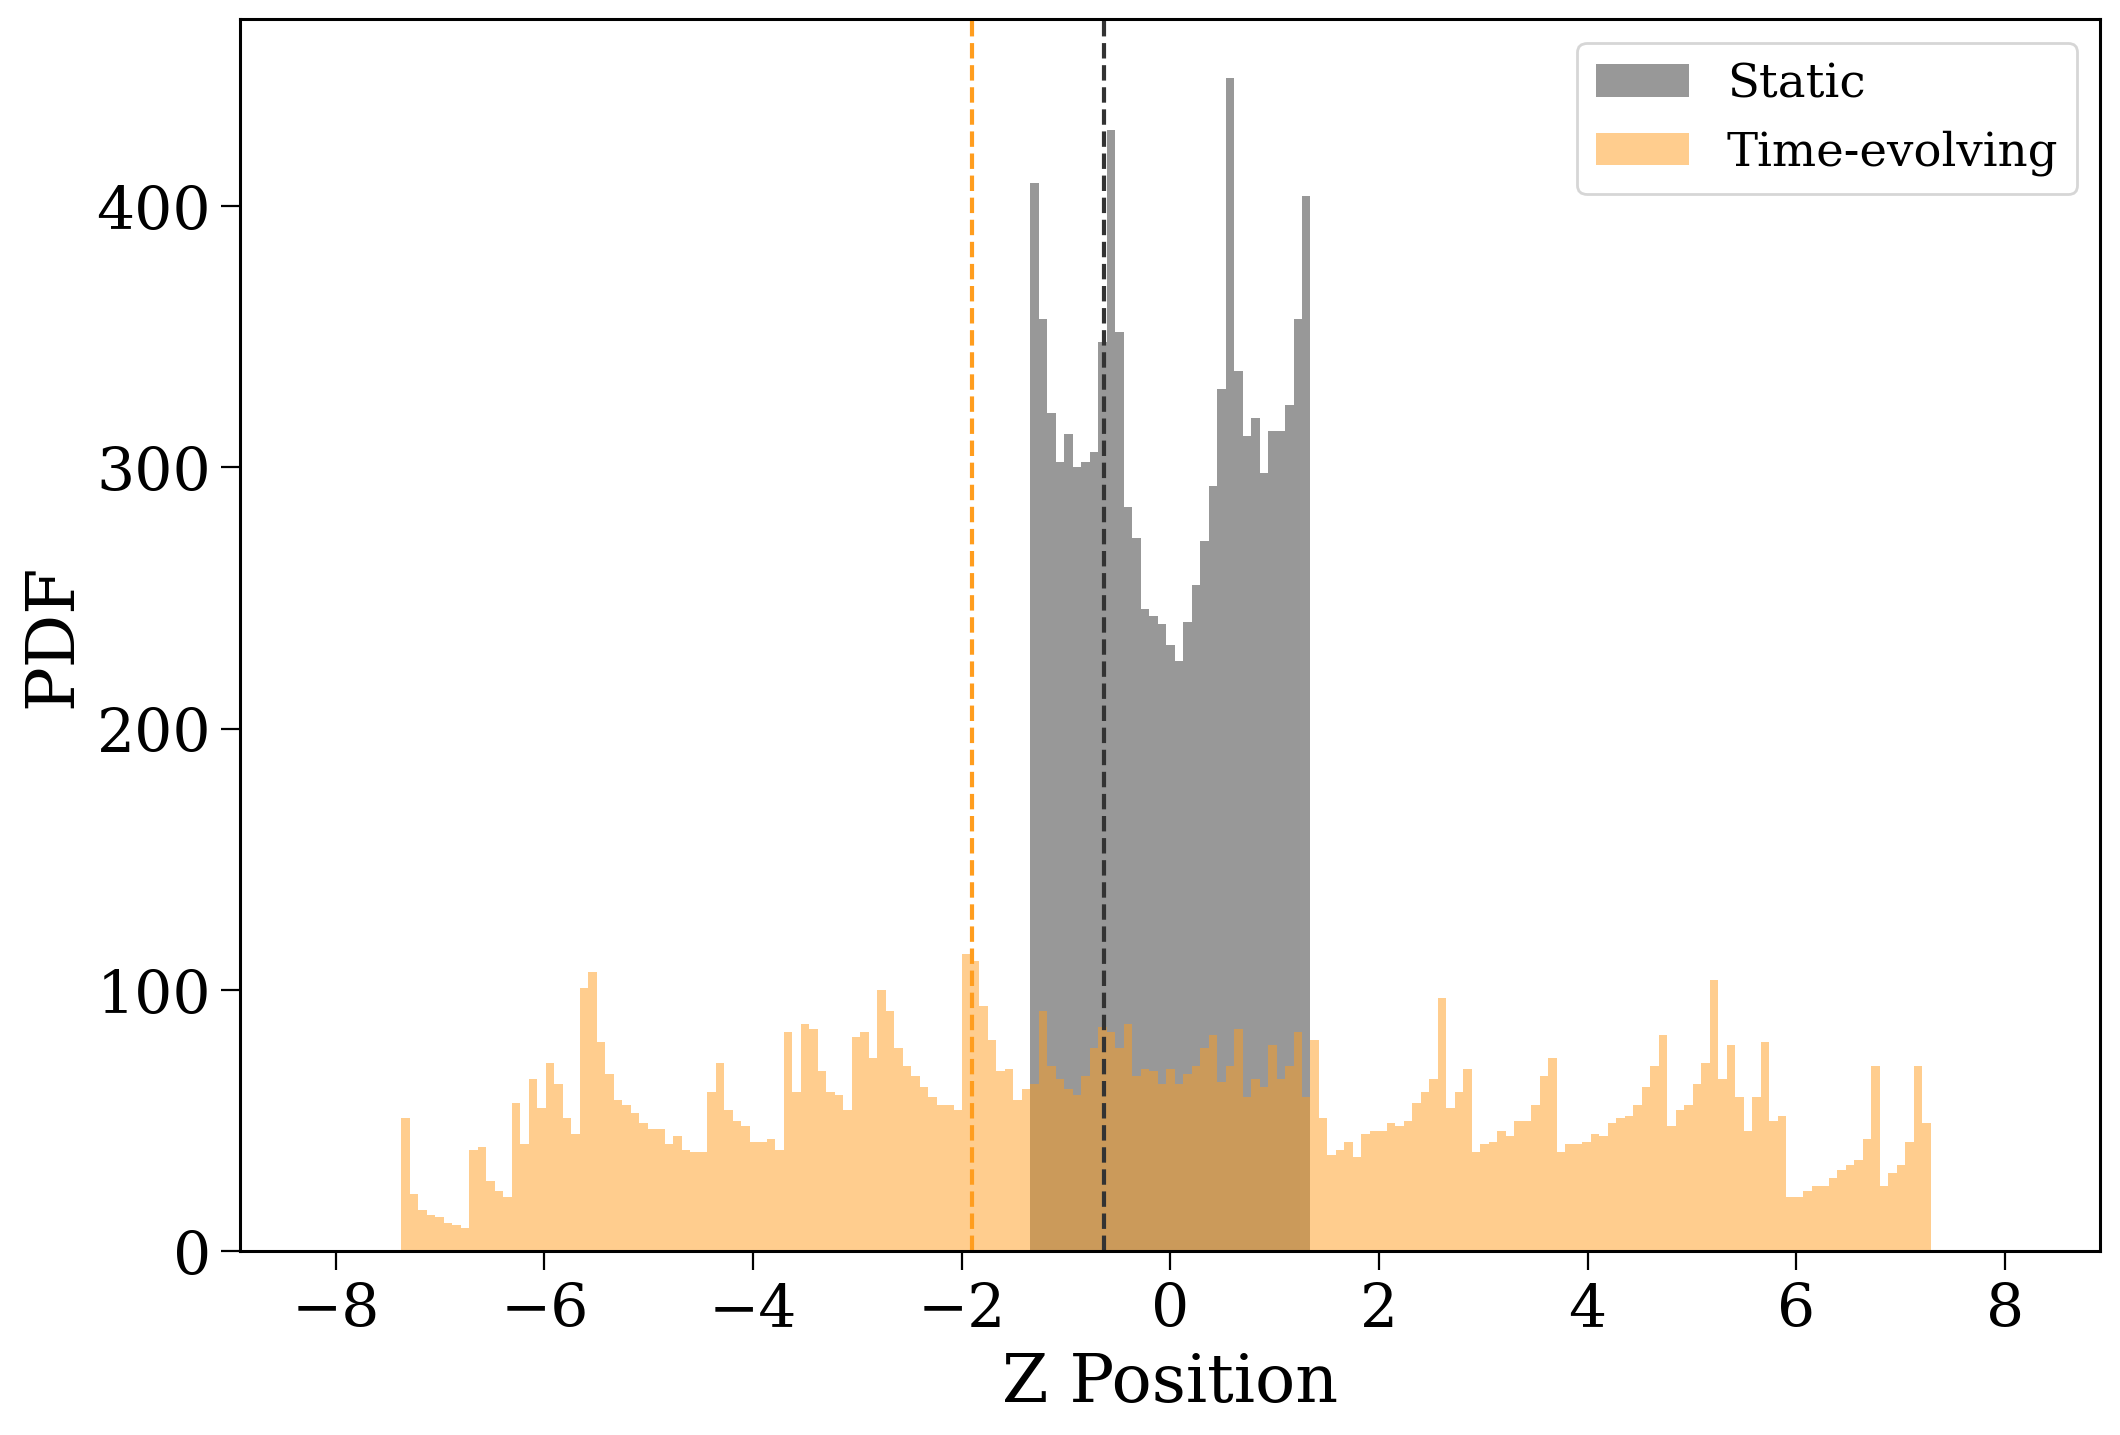

In [90]:
ORB = 16
t_max = 100 * u.Gyr

labels = ["Static", "Time-evolving"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for pop, col, label in zip(smol_pops, colours, labels):
    orbit = pop.orbits[ORB]
    orbit = orbit[orbit.t - orbit.t[0] < t_max]
    orbit.plot(axes=axes, alpha=0.5, zorder=-1, color=col)
    axes[0].scatter(orbit.x[0], orbit.y[0], color="k", marker="x", s=100)
    axes[0].scatter(orbit.x[-1], orbit.y[-1], marker="+", s=100, color=col)
    axes[1].scatter(orbit.x[0], orbit.z[0], color="k", marker="x", s=100)
    axes[1].scatter(orbit.x[-1], orbit.z[-1], marker="+", s=100, color=col)
    axes[2].scatter(orbit.y[0], orbit.z[0], color="k", marker="x", s=100)
    axes[2].scatter(orbit.y[-1], orbit.z[-1], marker="+", s=100, color=col)

plt.show()

fig, ax = plt.subplots()

for pop, col, label in zip(smol_pops, colours, labels):
    orbit = pop.orbits[ORB]
    ax.plot(orbit.t, orbit.z, alpha=0.5, zorder=-1, color=col, label=label)
    ax.axhline(orbit.z[-1].value, color=col, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Z Position")
ax.legend()

plt.show()

fig, ax = plt.subplots()

max_z = max([np.max(np.abs(pop.orbits[ORB].z.value)) for pop in smol_pops])

for pop, col, label in zip(smol_pops, colours, labels):
    orbit = pop.orbits[ORB]
    ax.hist(orbit.z.value, bins=np.linspace(-max_z * 1.1, max_z * 1.1, 200), alpha=0.5, color=col, label=label)
    ax.axvline(orbit.z[-1].value, color=col, linestyle="--")

ax.set_xlabel("Z Position")
ax.set_ylabel("PDF")
ax.legend()

plt.show()

## NSNS mergers?

In [91]:
merger_dists = []

for pop in [evolving_pop, static_pop]:
    ever_ns_ns = (pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 13) & (pop.bpp["sep"] > 0)
    merger = pop.final_bpp["sep"] == 0

    nsns_merger = np.isin(pop.bin_nums, pop.bpp[ever_ns_ns]["bin_num"]) & merger
    
    nsns_pop = pop[nsns_merger]
    nsns_pop.store_entire_orbits = True
    nsns_pop.processes = 28
    nsns_pop.perform_galactic_evolution()

    merger_time = nsns_pop.bpp[(nsns_pop.bpp["kstar_1"] == 13) & (nsns_pop.bpp["kstar_2"] == 13)].drop_duplicates(subset=["bin_num"], keep='last')["tphys"].values

    merger_inds = [np.argmin(np.abs(nsns_pop.orbits[i].t - (12 * u.Gyr - nsns_pop.initial_galaxy[i].tau) - merger_time[i] * u.Myr)) for i in range(len(nsns_pop))]

    merger_dist = [np.linalg.norm(nsns_pop.orbits[i].pos[merger_inds[i]].xyz).to(u.kpc).value for i in range(len(nsns_pop))] * u.kpc

    print(merger_dist, merger_time)

    merger_dists.append(merger_dist)

merger_dists[0] / merger_dists[1]

Integrating orbits: 100%|██████████| 117/117 [00:00<00:00, 475.88it/s]


[1.30151038e+01 2.14193277e+01 9.98362286e+01 8.01419952e+01
 3.01361864e+02 3.58754266e+01 1.76199471e+01 8.39882939e+00
 2.99796643e+00 1.56402211e+01 2.13043999e+01 1.38408485e+01
 1.36520109e+01 2.22255851e+01 1.79163238e+01 1.19638413e+01
 6.61288276e+00 2.64588380e+01 9.37481441e+00 7.56199094e+00
 1.66015253e+01 1.08994366e+01 1.54948728e+01 1.48303029e+01
 2.73888516e+01 2.15019144e+01 6.75674086e+00 1.53153513e+01
 2.39662274e+01 2.45247113e+01 7.03848411e+00 8.98483972e+00
 1.86801060e+00 9.93727278e+00 2.10930918e+02 1.56988896e+01
 2.82175291e+02 1.43751120e+01 6.35266882e+00 1.13033221e+01
 7.41271106e+00 2.85604355e+00 4.52086206e+00 3.83150164e+00
 8.94756285e+00 7.33036932e+01 2.33061073e+01 7.77470540e+00
 1.12685972e+02 5.30329805e+00 6.05833325e+00 1.97981946e+01
 2.68455026e+01 5.63995372e-01 1.33890944e+01 4.92838485e+00
 1.09268608e+01 7.30139953e+00 3.51696504e+00 4.56887273e+00
 1.05568151e+02 6.17480741e+01 8.89430687e+00 7.22865204e+00
 3.06486875e+01 3.334061

Integrating orbits: 100%|██████████| 117/117 [00:00<00:00, 400.51it/s]


[8.38506002e+00 2.01626966e+01 1.01464725e+02 5.32859594e+01
 1.62397038e+02 5.19927942e+01 1.63749932e+01 7.46787017e+00
 1.18408701e+01 1.45898447e+01 1.10207992e+01 1.30760523e+01
 1.24772946e+01 2.18389006e+01 1.71661623e+01 1.15577261e+01
 5.54456791e+00 3.49175982e+01 5.29111264e+00 7.21653135e+00
 4.31680061e+00 8.40680208e+00 1.33153373e+01 9.72488978e+00
 1.13023911e+01 1.40701223e+01 9.32858689e+00 1.59911796e+01
 2.26637392e+01 2.41079619e+01 6.68889032e+00 8.18776274e+00
 3.51823764e+00 4.60118965e+00 1.98900997e+02 1.41215847e+01
 4.41378428e+01 1.38126543e+01 4.73697556e+00 1.08279267e+01
 7.01206713e+00 3.78823432e+00 2.39127601e+00 2.65074957e+00
 8.01589529e+00 2.36929065e+01 6.29518212e+00 3.16933657e+00
 5.68921281e+01 4.08070384e+00 7.87206621e+00 1.91085383e+01
 2.44590490e+01 4.91541954e-01 9.78805584e+00 5.61965973e+00
 6.67144539e+00 6.38125355e+00 3.21385462e+00 4.01863753e+00
 1.18530201e+01 2.74944788e+01 7.10317077e+00 6.11702573e+00
 2.62584152e+01 2.985299

<Quantity [1.55217777, 1.06232456, 0.98395012, 1.50399835, 1.85571035,
           0.69000767, 1.07602775, 1.12466194, 0.25318802, 1.07199367,
           1.93310843, 1.05848831, 1.09414832, 1.01770623, 1.04370001,
           1.03513798, 1.19267775, 0.7577508 , 1.77180398, 1.04787059,
           3.84579386, 1.2965021 , 1.16368609, 1.52498417, 2.42327941,
           1.52819669, 0.72430486, 0.95773743, 1.05747013, 1.01728679,
           1.05226484, 1.09734979, 0.53095066, 2.15971815, 1.06048195,
           1.11169461, 6.39304671, 1.04072046, 1.34108119, 1.04390457,
           1.05713635, 0.75392473, 1.89056472, 1.44544082, 1.11622751,
           3.09390886, 3.70221335, 2.45310185, 1.98069532, 1.29960376,
           0.76959887, 1.03609153, 1.09756935, 1.14740027, 1.36790131,
           0.87698991, 1.63785509, 1.14419518, 1.09431367, 1.13692083,
           8.9064348 , 2.24583541, 1.25216008, 1.1817266 , 1.16719487,
           1.11682631, 3.97441665, 1.0456023 , 1.41882199, 1.83145544,
      

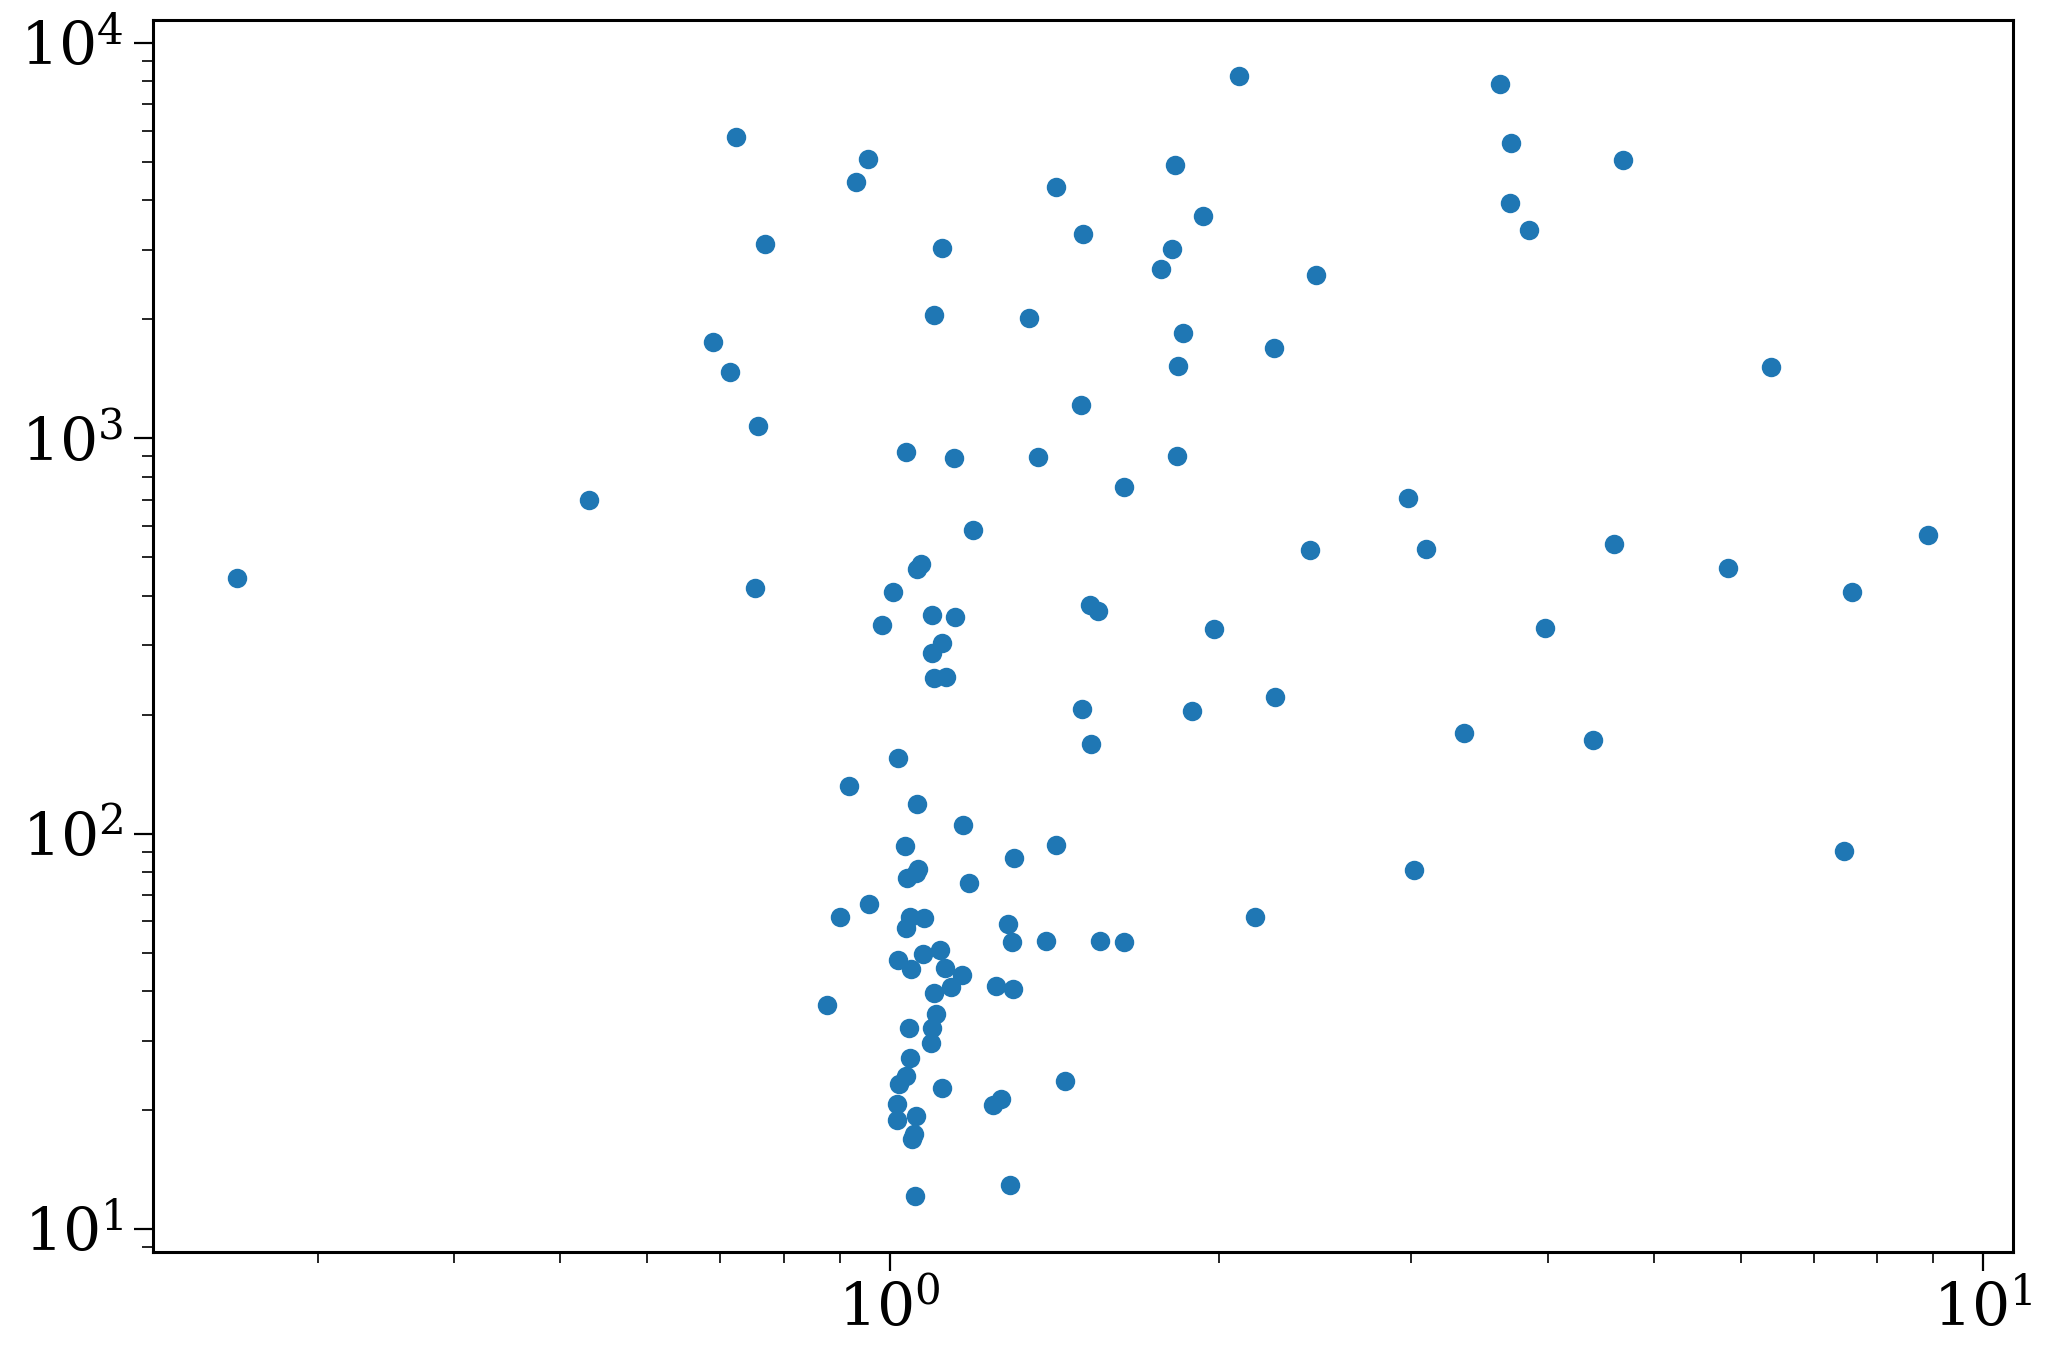

In [100]:
plt.scatter(merger_dists[0] / merger_dists[1], merger_time)
plt.xscale("log")
plt.yscale("log")

## BHBH mergers?

In [102]:
merger_dists = []

for pop in [evolving_pop, static_pop]:
    ever_bh_bh = (pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 14) & (pop.bpp["sep"] > 0)
    merger = pop.final_bpp["sep"] == 0

    bhbh_merger = np.isin(pop.bin_nums, pop.bpp[ever_bh_bh]["bin_num"]) & merger
    
    print(len(bhbh_merger))

    bhbh_pop = pop[bhbh_merger]
    bhbh_pop.store_entire_orbits = True
    bhbh_pop.processes = 28
    bhbh_pop.perform_galactic_evolution()

#     merger_time = bhbh_pop.bpp[(bhbh_pop.bpp["kstar_1"] == 14) & (bhbh_pop.bpp["kstar_2"] == 14)].drop_duplicates(subset=["bin_num"], keep='last')["tphys"].values

#     merger_inds = [np.argmin(np.abs(bhbh_pop.orbits[i].t - (12 * u.Gyr - bhbh_pop.initial_galaxy[i].tau) - merger_time[i] * u.Myr)) for i in range(len(bhbh_pop))]

#     merger_dist = [np.linalg.norm(bhbh_pop.orbits[i].pos[merger_inds[i]].xyz).to(u.kpc).value for i in range(len(bhbh_pop))] * u.kpc

#     print(merger_dist, merger_time)

#     merger_dists.append(merger_dist)

# merger_dists[0] / merger_dists[1]

834575


Integrating orbits: 100%|██████████| 866/866 [00:01<00:00, 687.75it/s] 


834576


Integrating orbits: 100%|██████████| 866/866 [00:01<00:00, 813.11it/s] 


(array([ 1.,  0.,  0.,  1.,  6.,  6., 48., 16., 13.,  7.,  2.,  5.,  5.,
         2.,  2.,  3.]),
 array([-0.59655685, -0.49991556, -0.40327426, -0.30663296, -0.20999167,
        -0.11335037, -0.01670907,  0.07993222,  0.17657352,  0.27321482,
         0.36985611,  0.46649741,  0.56313871,  0.65978   ,  0.7564213 ,
         0.8530626 ,  0.94970389]),
 <BarContainer object of 16 artists>)

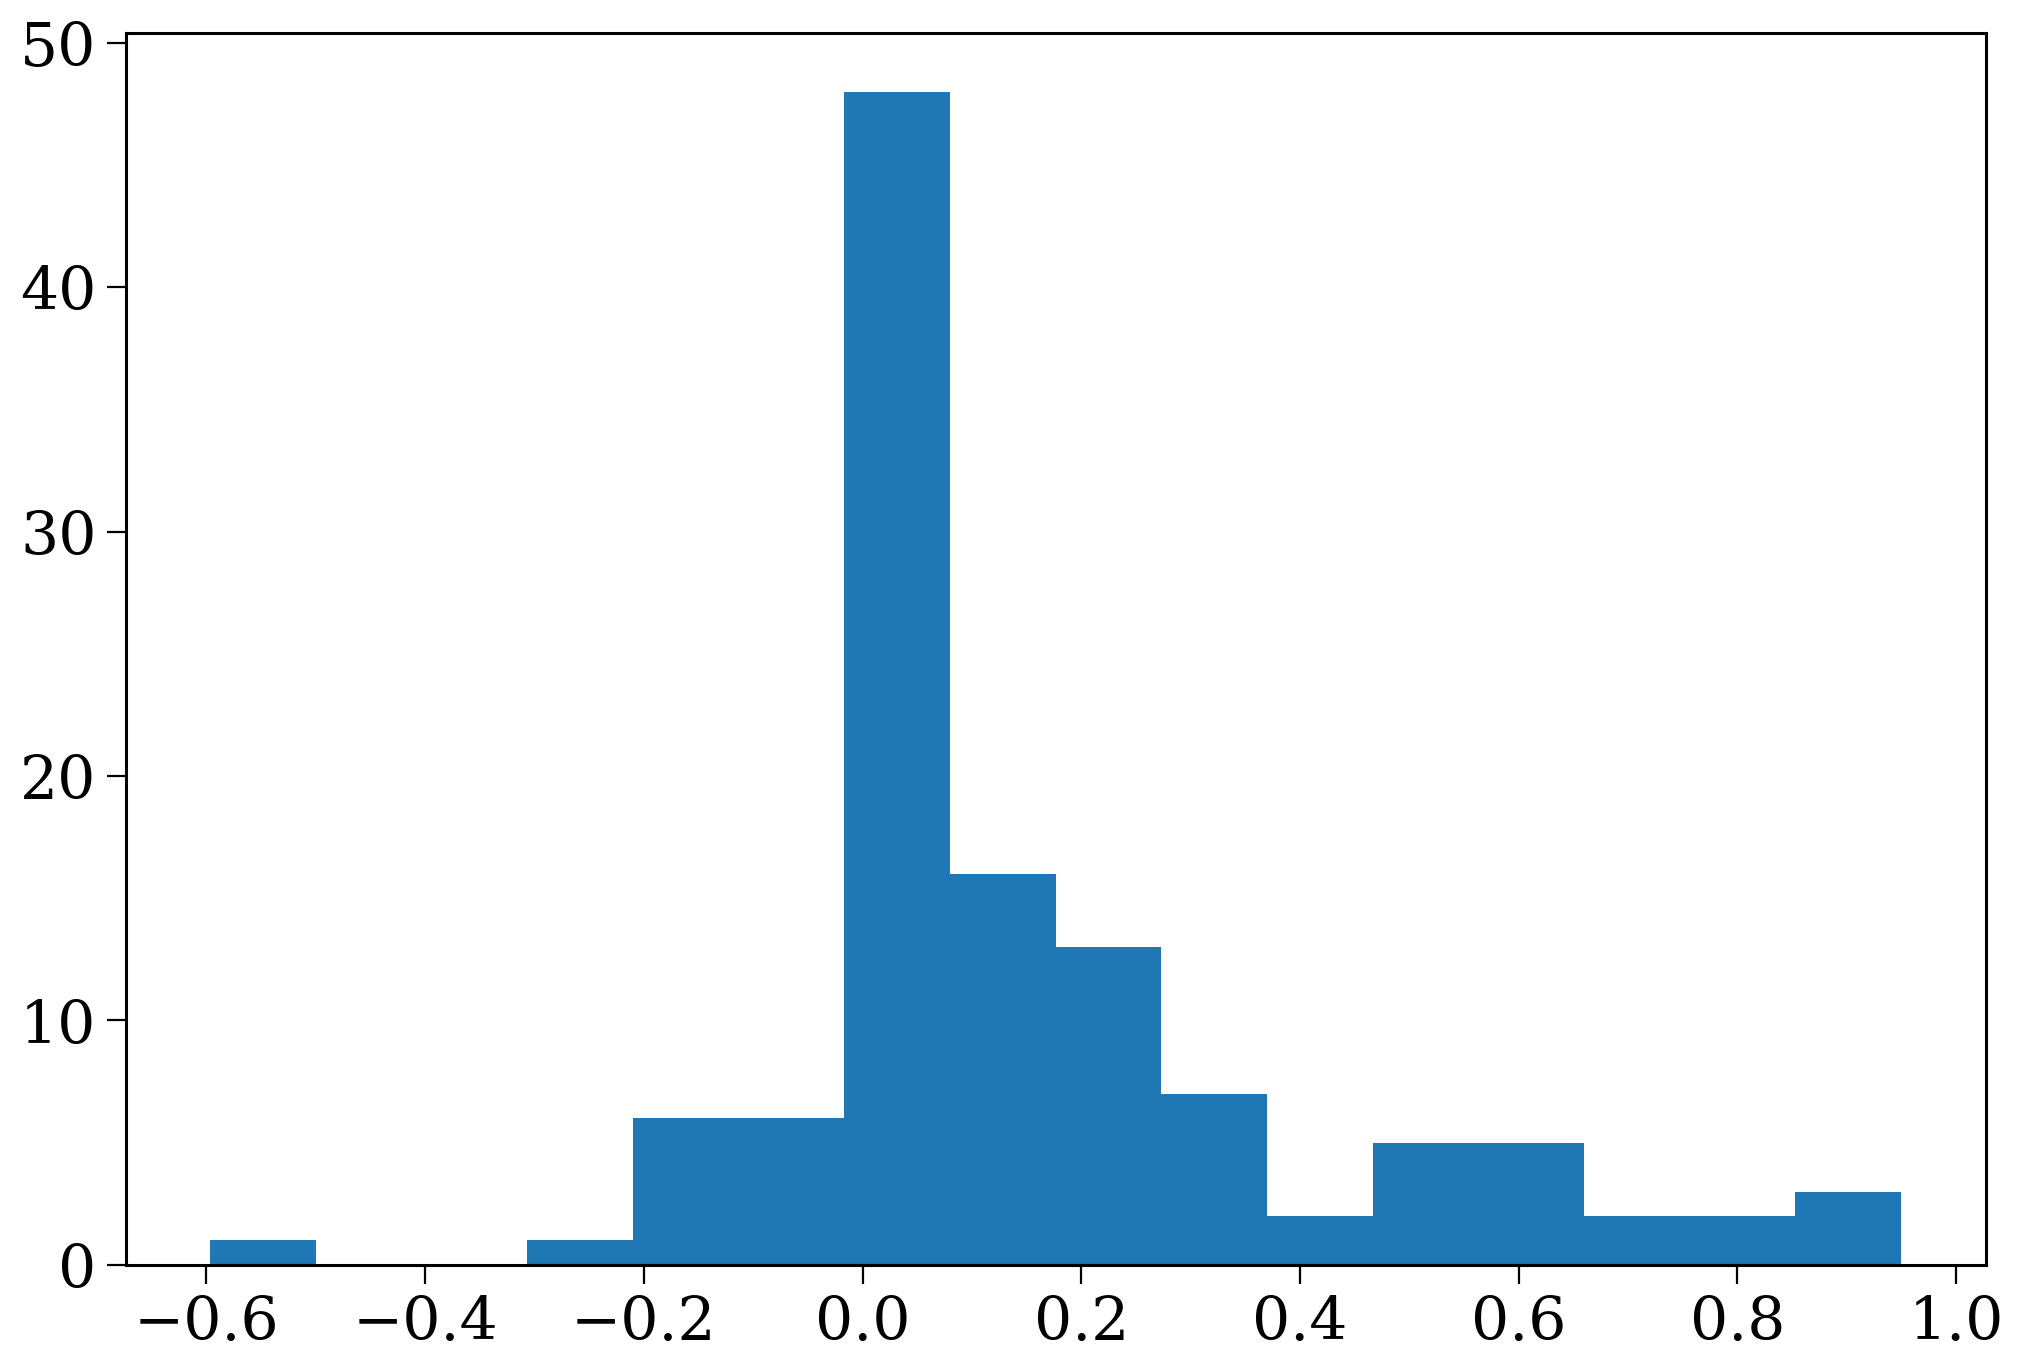

In [96]:
plt.hist(np.log10(merger_dists[0] / merger_dists[1]), bins="auto")